In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df_train = pd.read_csv('./train_loanset_2010_2014.csv')
df_test = pd.read_csv('./test_loanset_2015.csv')


C:\Users\59907\AppData\Local\Temp\ipykernel_43420\305444996.py:1: DtypeWarning: Columns (19,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('./train_loanset_2010_2014.csv')
C:\Users\59907\AppData\Local\Temp\ipykernel_43420\305444996.py:2: DtypeWarning: Columns (19,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('./test_loanset_2015.csv')


In [ ]:
import os
os.makedirs('temp', exist_ok=True)
df_train.isnull().mean().to_frame('missing_rate').to_csv('temp/df_train_missing_rate.csv')

# Utils

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_categorical_pie_with_others(
    df,
    col,
    method="top_n",
    top_n=10,
    threshold=0.01,
    others_label="Others",
    missing_label="Missing",
    figsize=(10, 10),
    autopct="%1.1f%%",
    startangle=90,
    show=True,
):
    """
    Collapse high-cardinality categories, then plot a pie chart.

    Parameters
    ----------
    df : pandas.DataFrame
        Input data.
    col : str
        Categorical column name.
    method : str
        How to keep categories:
        - 'top_n': keep the top `top_n` categories by count; merge the rest into Others.
        - 'threshold': keep categories with share >= `threshold`; merge the rest into Others.
    top_n : int
        Used when method='top_n'.
    threshold : float
        Minimum share when method='threshold' (e.g. 0.01 = 1%).
    others_label : str
        Label for merged small categories.
    missing_label : str
        Label used for missing values before grouping.
    figsize : tuple
        Figure size.
    autopct : str
        Format for percentage labels on the pie.
    startangle : int
        Pie start angle in degrees.
    show : bool
        If True, display the figure.

    Returns
    -------
    grouped_counts : pandas.Series
        Category counts after merging.
    grouped_ratio : pandas.Series
        Category proportions after merging.
    """
    s = df[col].copy()
    s = s.fillna(missing_label)

    counts = s.value_counts(dropna=False)
    total = counts.sum()

    if method == "top_n":
        keep_labels = counts.head(top_n).index
    elif method == "threshold":
        ratios = counts / total
        keep_labels = ratios[ratios >= threshold].index
    else:
        raise ValueError("method must be 'top_n' or 'threshold'")

    s_grouped = s.apply(lambda x: x if x in keep_labels else others_label)

    grouped_counts = s_grouped.value_counts()
    grouped_ratio = grouped_counts / grouped_counts.sum()

    if show:
        plt.figure(figsize=figsize)
        plt.pie(
            grouped_counts,
            labels=grouped_counts.index,
            autopct=autopct,
            startangle=startangle,
        )
        plt.title(f"{col} distribution ({method} with Others)")
        plt.axis("equal")
        plt.show()

    return grouped_counts, grouped_ratio

In [ ]:
def count_unique_values_one(df, output_excel=None):
    """
    Count the number of unique values per column and list columns with exactly one unique value.
    Optionally save those columns to an Excel file.

    Parameters
    ----------
    df : pandas.DataFrame
        Input data.
    output_excel : str or None
        If set, save columns with unique count == 1 to this Excel path.

    Returns
    -------
    unique_one_vars : list of str
        Column names whose number of unique values (excluding NaN) is 1.
    """
    unique_counts = df.nunique(dropna=True)

    unique_one = unique_counts[unique_counts == 1].index.tolist()

    if unique_one:
        print("Columns with exactly one unique value:", unique_one)
    else:
        print("No columns with exactly one unique value.")

    if output_excel:
        if unique_one:
            unique_one_df = pd.DataFrame(
                {"variable": unique_one, "unique_count": [1] * len(unique_one)}
            )
            unique_one_df.to_excel(output_excel, index=False)
            print(f"Columns with unique count == 1 saved to '{output_excel}'")
        else:
            print("No columns with exactly one unique value; Excel file not written.")

    return unique_one

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun"]
plt.rcParams["axes.unicode_minus"] = False


def _compute_woe_series(d, bin_col, target, eps):
    bad = d[target] == 1
    good = d[target] == 0
    n_bad = bad.sum()
    n_good = good.sum()
    if n_bad == 0 or n_good == 0:
        return None
    tmp = d.assign(_good=good.astype(int), _bad=bad.astype(int))
    agg = tmp.groupby(bin_col, dropna=False, observed=True).agg(
        good=("_good", "sum"),
        bad=("_bad", "sum"),
    )
    dist_good = (agg["good"] + eps) / (n_good + eps * len(agg))
    dist_bad = (agg["bad"] + eps) / (n_bad + eps * len(agg))
    return np.log(dist_good / dist_bad)


def _assign_bins_train(s, bins, method, force_bins):
    """Return (binned Series, bin_edges or None). bin_edges for pd.cut on test when numeric."""
    s_clean = s
    if force_bins and method == "equal_width":
        cat, edges = pd.cut(s_clean, bins=bins, duplicates="drop", retbins=True)
        return cat, edges
    if force_bins and method == "quantile":
        rk = s_clean.rank(method="first")
        cat, edges = pd.qcut(rk, q=bins, duplicates="drop", retbins=True)
        return cat, edges
    if method == "quantile":
        try:
            cat, edges = pd.qcut(s_clean, q=bins, duplicates="drop", retbins=True)
        except ValueError:
            b = min(bins, s_clean.nunique(dropna=True))
            cat, edges = pd.cut(s_clean, bins=b, duplicates="drop", retbins=True)
        return cat, edges
    cat, edges = pd.cut(s_clean, bins=bins, duplicates="drop", retbins=True)
    return cat, edges


def plot_bad_rate_by_bin(
    df,
    col,
    target="target",
    bins=10,
    method="quantile",
    force_bins=False,
    eps=1e-6,
    figsize=None,
    show=True,
    save_path=None,
):
    """
    Train bins on df, plot bad rate per bin, compute WOE per bin (train).

    Returns
    -------
    bundle : dict or None
        use_bins, bin_edges, col, target, woe_map, method, bins, force_bins, eps
    """
    if col not in df.columns or target not in df.columns:
        raise KeyError(f"Missing column: {col!r} or {target!r}")

    d = df[[col, target]].dropna(subset=[target]).copy()
    s = d[col]

    if pd.api.types.is_bool_dtype(s):
        use_bins = False
    elif pd.api.types.is_numeric_dtype(s) and s.nunique(dropna=True) > bins:
        use_bins = True
    else:
        use_bins = False

    bin_edges = None
    if use_bins:
        d["_bin"], bin_edges = _assign_bins_train(s, bins, method, force_bins)
    else:
        d["_bin"] = s

    bad = d[target] == 1
    good = d[target] == 0
    if bad.sum() == 0 or good.sum() == 0:
        print("target must contain both 0 and 1.")
        return None

    woe = _compute_woe_series(d, "_bin", target, eps)
    if woe is None:
        return None

    grp = (
        d.groupby("_bin", observed=True)[target]
        .agg(bad_rate="mean", n="count")
        .sort_index()
    )
    x_labels = [str(i) for i in grp.index]
    rates = grp["bad_rate"].to_numpy(dtype=float)
    counts = grp["n"].to_numpy(dtype=int)

    if len(rates) == 0:
        print("No valid data; skip plotting.")
        return None

    if figsize is None:
        figsize = (max(10, 0.32 * len(x_labels)), 5.5)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(x_labels))
    bars = ax.bar(
        x,
        rates,
        color=(0.49, 0.78, 0.85),
        edgecolor="black",
        linewidth=0.6,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=90, ha="center")
    ax.set_xlabel(f"{col} (bins)")
    ax.set_ylabel("Bad rate")
    ax.set_title(f"{col}: bad rate by bin (train)")
    ax.grid(axis="y", linestyle="--", alpha=0.45)
    ax.set_axisbelow(True)

    top = float(np.nanmax(rates))
    ax.set_ylim(0, max(top * 1.25, top + 0.005, 0.025))

    dy = max(top * 0.02, 0.002)
    for bar, rate, n in zip(bars, rates, counts):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + dy,
            f"{100 * rate:.2f}%\n(n={n})",
            ha="center",
            va="bottom",
            fontsize=7,
        )

    plt.tight_layout()
    if save_path is not None:
        p = Path(save_path)
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, bbox_inches="tight", dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)

    bundle = {
        "col": col,
        "target": target,
        "use_bins": use_bins,
        "bin_edges": bin_edges,
        "woe_map": woe.rename("woe"),
        "method": method,
        "bins": bins,
        "force_bins": force_bins,
        "eps": eps,
    }
    return bundle


def apply_bad_rate_bins(df, bundle):
    """Same bins as training; returns binned Series (Interval or raw category)."""
    col = bundle["col"]
    s = df[col]
    if bundle["use_bins"]:
        return pd.cut(s, bins=bundle["bin_edges"], include_lowest=True)
    return s


def map_to_train_woe(binned_series, bundle):
    woe_map = bundle["woe_map"]
    return binned_series.map(woe_map)


def col_to_bad_rate_woe(df, bundle, fillna_woe=0.0):
    return map_to_train_woe(apply_bad_rate_bins(df, bundle), bundle, fillna_woe)


# Example
# b = plot_bad_rate_by_bin(df_train_3, "dti", bins=10, method="quantile", force_bins=True)
# df_test_3["dti_br_woe"] = col_to_bad_rate_woe(df_test_3, b)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _fit_bin_edges(s: pd.Series, bins: int, method: str):
    """Fit bin edges on training column (non-null only)."""
    s = s.dropna()
    if len(s) == 0:
        return None, "empty"
    if method == "quantile":
        try:
            _, edges = pd.qcut(s, q=bins, duplicates="drop", retbins=True)
        except ValueError:
            b = min(bins, max(2, s.nunique(dropna=True)))
            _, edges = pd.cut(s, bins=b, duplicates="drop", retbins=True)
    else:
        _, edges = pd.cut(s, bins=bins, duplicates="drop", retbins=True)
    return edges, "edges"


def _compute_woe_series(d, bin_col, target, eps):
    bad = d[target] == 1
    good = d[target] == 0
    n_bad = bad.sum()
    n_good = good.sum()
    if n_bad == 0 or n_good == 0:
        return None
    tmp = d.assign(_good=good.astype(int), _bad=bad.astype(int))
    agg = tmp.groupby(bin_col, dropna=False, observed=True).agg(
        good=("_good", "sum"),
        bad=("_bad", "sum"),
    )
    dist_good = (agg["good"] + eps) / (n_good + eps * len(agg))
    dist_bad = (agg["bad"] + eps) / (n_bad + eps * len(agg))
    woe = np.log(dist_good / dist_bad)
    return woe


def plot_woe_by_bin(
    df,
    col,
    target="target",
    bins=10,
    method="quantile",
    figsize=None,
    eps=1e-6,
    show=True,
    save_path=None,
):
    """
    Train binning + WOE on df (use training data only). Plot WOE per bin.

    Returns
    -------
    bundle : dict or None
        Keys: col, target, use_bins, bin_edges (or None), woe_map (Series), method, bins, eps
    """
    if col not in df.columns or target not in df.columns:
        raise KeyError(f"Missing column: {col!r} or {target!r}")

    d = df[[col, target]].dropna(subset=[target]).copy()
    s = d[col]

    if pd.api.types.is_bool_dtype(s):
        use_bins = False
    elif pd.api.types.is_numeric_dtype(s) and s.nunique(dropna=True) > bins:
        use_bins = True
    else:
        use_bins = False

    bin_edges = None
    if use_bins:
        bin_edges, _ = _fit_bin_edges(s, bins, method)
        if bin_edges is None:
            print("No valid data; skip plotting.")
            return None
        d["_bin"] = pd.cut(s, bins=bin_edges, include_lowest=True)
        bin_col = "_bin"
    else:
        d["_bin"] = s
        bin_col = "_bin"

    bad = d[target] == 1
    good = d[target] == 0
    n_bad = bad.sum()
    n_good = good.sum()
    if n_bad == 0 or n_good == 0:
        print("target must contain both 0 and 1.")
        return None

    woe = _compute_woe_series(d, bin_col, target, eps)
    if woe is None:
        return None

    woe = woe.sort_index()
    woe_vals = woe.to_numpy(dtype=float)
    x_labels = [str(i) for i in woe.index]

    if len(woe_vals) == 0:
        print("No valid data; skip plotting.")
        return None

    if figsize is None:
        figsize = (max(10, 0.32 * len(x_labels)), 5.5)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(x_labels))
    colors = [
        (0.49, 0.78, 0.85) if w >= 0 else (0.95, 0.65, 0.65)
        for w in woe_vals
    ]
    bars = ax.bar(x, woe_vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=90, ha="center")
    ax.set_xlabel(f"{col} (bins)")
    ax.set_ylabel("WOE")
    ax.set_title(f"{col}: WOE by bin (train)")
    ax.grid(axis="y", linestyle="--", alpha=0.45)
    ax.set_axisbelow(True)

    ymax = float(np.nanmax(np.abs(woe_vals)))
    ax.set_ylim(-ymax * 1.15 - 0.05, ymax * 1.15 + 0.05)

    dy = max(ymax * 0.02, 0.05)
    for bar, w in zip(bars, woe_vals):
        h = bar.get_height()
        y0 = h + dy if h >= 0 else h - dy
        va = "bottom" if h >= 0 else "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y0,
            f"{w:.3f}",
            ha="center",
            va=va,
            fontsize=7,
        )

    plt.tight_layout()
    if save_path is not None:
        p = Path(save_path)
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, bbox_inches="tight", dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)

    bundle = {
        "col": col,
        "target": target,
        "use_bins": use_bins,
        "bin_edges": bin_edges,
        "woe_map": woe.rename("woe"),
        "method": method,
        "bins": bins,
        "eps": eps,
    }
    return bundle


def apply_woe_bins(df, bundle):
    """
    Assign the same bin labels as training (Interval or category), aligned to df.index.
    """
    col = bundle["col"]
    s = df[col]

    if bundle["use_bins"]:
        return pd.cut(s, bins=bundle["bin_edges"], include_lowest=True)
    return s


def map_to_train_woe(binned_series, bundle):
    """Map bin labels to train WOE; unknown/missing bins -> NaN."""
    woe_map = bundle["woe_map"]
    return binned_series.map(woe_map)


# 示例
# bundle = plot_woe_by_bin(df_train_3, "dti", target="target", bins=10, method="quantile")
# bins_test = apply_woe_bins(df_test_3, bundle)
# woe_test = map_to_train_woe(bins_test, bundle)

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier


def _woe_per_leaf(sub, leaf_col, target, eps=1e-6):
    """WOE per leaf id (train only)."""
    bad = sub[target] == 1
    good = sub[target] == 0
    n_bad = int(bad.sum())
    n_good = int(good.sum())
    if n_bad == 0 or n_good == 0:
        return None
    tmp = sub.assign(_good=good.astype(int), _bad=bad.astype(int))
    agg = tmp.groupby(leaf_col, observed=True).agg(
        good=("_good", "sum"),
        bad=("_bad", "sum"),
    )
    dist_good = (agg["good"] + eps) / (n_good + eps * len(agg))
    dist_bad = (agg["bad"] + eps) / (n_bad + eps * len(agg))
    woe = np.log(dist_good / dist_bad)
    return woe


def plot_decision_tree_bins(
    df,
    col,
    target="target",
    max_leaf_nodes=8,
    min_samples_leaf=0.05,
    random_state=0,
    figsize=None,
    show=True,
    save_path=None,
    eps=1e-6,
):
    """
    Fit single-variable tree on train, plot mean(target) per leaf.

    Returns
    -------
    bundle : dict or None
        clf, is_numeric, uniques, col, target, woe_map (Series: leaf_id -> WOE on train), eps
    """
    sub = df[[col, target]].dropna().copy()
    if sub.empty:
        print("No valid data.")
        return None
    y = sub[target].astype(int).to_numpy()
    if len(np.unique(y)) < 2:
        print("target must contain both 0 and 1.")
        return None

    raw = sub[col]
    if pd.api.types.is_numeric_dtype(raw):
        X = raw.to_numpy(dtype=float).reshape(-1, 1)
        is_numeric = True
        uniques = None
    else:
        codes, uniques = pd.factorize(raw, sort=True)
        X = codes.astype(float).reshape(-1, 1)
        is_numeric = False

    msl = min_samples_leaf
    if isinstance(msl, float) and msl < 1:
        msl = max(1, int(np.ceil(msl * len(sub))))

    clf = DecisionTreeClassifier(
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=msl,
        random_state=random_state,
    )
    clf.fit(X, y)

    sub["_leaf"] = clf.apply(X)

    woe_map = _woe_per_leaf(sub, "_leaf", target, eps=eps)
    if woe_map is None:
        return None

    agg = sub.groupby("_leaf", sort=True).agg(
        rate=(target, "mean"),
        n=(target, "size"),
        lo=(col, "min"),
        hi=(col, "max"),
    )

    if is_numeric:
        labels = [f"[{row.lo:.4g}, {row.hi:.4g}]" for _, row in agg.iterrows()]
    else:
        labels = []
        for leaf_id, row in agg.iterrows():
            part = sub.loc[sub["_leaf"] == leaf_id, col]
            cats = part.value_counts().head(3).index.tolist()
            tail = "…" if part.nunique() > 3 else ""
            labels.append(",".join(map(str, cats)) + tail)

    rates = agg["rate"].to_numpy()
    counts = agg["n"].to_numpy()
    order = np.argsort(agg["lo"].to_numpy() if is_numeric else np.arange(len(agg)))
    labels = [labels[i] for i in order]
    rates = rates[order]
    counts = counts[order]

    if figsize is None:
        figsize = (max(8, 0.45 * len(labels)), 5)

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(labels))
    bars = ax.bar(
        x,
        rates,
        color=(0.49, 0.78, 0.85),
        edgecolor="black",
        linewidth=0.6,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel(f"{col} (bins from decision tree)")
    ax.set_ylabel("Mean target in bin")
    ax.set_title(f"{col}: tree bins vs mean target")
    ax.grid(axis="y", linestyle="--", alpha=0.45)
    ax.set_axisbelow(True)
    top = float(np.nanmax(rates)) if len(rates) else 0
    ax.set_ylim(0, max(top * 1.2, top + 0.01, 0.05))
    dy = max(top * 0.02, 0.002)
    for bar, r, n in zip(bars, rates, counts):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + dy,
            f"{100 * r:.2f}%\nn={n}",
            ha="center",
            va="bottom",
            fontsize=7,
        )
    plt.tight_layout()
    if save_path is not None:
        p = Path(save_path)
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, bbox_inches="tight", dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)

    bundle = {
        "clf": clf,
        "is_numeric": is_numeric,
        "uniques": uniques,
        "col": col,
        "target": target,
        "woe_map": woe_map.rename("woe"),
        "eps": eps,
    }
    return bundle


def apply_decision_tree_bins(df, bundle, unknown_cat_code=0):
    """Same leaves as training; returns Series aligned to df.index."""
    col = bundle["col"]
    clf = bundle["clf"]
    is_numeric = bundle["is_numeric"]
    uniques = bundle["uniques"]

    raw = df[col]
    if is_numeric:
        X = raw.astype(float).to_numpy().reshape(-1, 1)
    else:
        codes = pd.Categorical(raw, categories=uniques).codes
        n_unknown = int((codes < 0).sum())
        if n_unknown > 0:
            warnings.warn(
                f"{n_unknown} rows have unseen categories in '{col}'; "
                f"mapping them to code {unknown_cat_code}.",
                UserWarning,
                stacklevel=2,
            )
        codes = np.where(codes < 0, unknown_cat_code, codes)
        X = codes.astype(float).reshape(-1, 1)

    leaf = clf.apply(X)
    return pd.Series(leaf, index=df.index, name="leaf")


def map_leaf_to_train_woe(leaf_series, bundle, fillna_woe=0.0):
    """leaf_id -> train WOE; unknown leaf -> fillna_woe."""
    return leaf_series.map(bundle["woe_map"]).fillna(fillna_woe)


def col_to_tree_woe(df, bundle, unknown_cat_code=0, fillna_woe=0.0):
    """One step: same as apply_decision_tree_bins + map_leaf_to_train_woe."""
    leaves = apply_decision_tree_bins(df, bundle, unknown_cat_code=unknown_cat_code)
    return map_leaf_to_train_woe(leaves, bundle, fillna_woe=fillna_woe)


# Example
# bundle = plot_decision_tree_bins(df_train_3, "dti", target="target")
# df_train_3["dti_tree_woe"] = col_to_tree_woe(df_train_3, bundle)
# df_test_3["dti_tree_woe"] = col_to_tree_woe(df_test_3, bundle)

In [ ]:
def map_grade_and_subgrade(df):
    """
    Map LendingClub `grade` and `sub_grade` to numeric scores.

    Returns a DataFrame with new columns `grade_numeric` and `sub_grade_numeric`,
    and drops the original `grade` and `sub_grade` columns.
    """
    grade_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}

    if "grade" in df.columns:
        df["grade_numeric"] = df["grade"].map(grade_mapping)

    if "sub_grade" in df.columns:
        df["letter"] = df["sub_grade"].str[0]
        df["number"] = df["sub_grade"].str[1:].astype(int)
        df["letter_numeric"] = df["letter"].map(grade_mapping)

        df["sub_grade_numeric"] = df["letter_numeric"] * 10 + df["number"]

        df.drop(columns=["letter", "number", "letter_numeric"], inplace=True)

    return df.drop(columns=["grade", "sub_grade"])



In [ ]:
def iv_summary(
    df,
    target="target",
    exclude=None,
    bins=10,
    numeric_min_unique=10,
    eps=1e-6,
):
    """
    Return a DataFrame with one row per feature: columns `variable` and `iv`.

    - target: binary 0/1; by default 1 = bad, 0 = good.
    - exclude: column names to skip (e.g. id, dates).
    - Numeric columns with many unique values: equal-frequency bins, then IV;
      otherwise treated as categorical (missing as its own level where applicable).
    """
    if exclude is None:
        exclude = set()
    else:
        exclude = set(exclude)

    exclude.add(target)
    d = df.dropna(subset=[target]).copy()
    if d[target].nunique() != 2:
        raise ValueError("target must be binary (0/1).")

    bad = d[target] == 1
    good = ~bad
    n_bad = bad.sum()
    n_good = good.sum()
    if n_bad == 0 or n_good == 0:
        raise ValueError("target must have both classes present (good and bad counts > 0).")

    rows = []

    for col in df.columns:
        if col in exclude:
            continue

        s = d[col]
        if pd.api.types.is_bool_dtype(s):
            x = s.astype("object")
        elif pd.api.types.is_numeric_dtype(s) and s.nunique(dropna=True) > numeric_min_unique:
            try:
                x = pd.qcut(s, q=bins, duplicates="drop")
            except ValueError:
                x = pd.cut(s, bins=min(bins, s.nunique(dropna=True)), duplicates="drop")
        else:
            x = s.astype("object")

        tmp = pd.DataFrame({"bin": x, "bad": bad.values.astype(int), "good": good.values.astype(int)})
        agg = tmp.groupby("bin", dropna=False, observed=True).agg(bad=("bad", "sum"), good=("good", "sum"))

        dist_bad = (agg["bad"] + eps) / (n_bad + eps * len(agg))
        dist_good = (agg["good"] + eps) / (n_good + eps * len(agg))

        woe = np.log(dist_good / dist_bad)
        iv = float(((dist_good - dist_bad) * woe).sum())
        rows.append((col, iv))

    out = pd.DataFrame(rows, columns=["variable", "iv"])
    return out.sort_values("iv", ascending=False).reset_index(drop=True)

# Briefly describe the data

## Deal with missing values

In [ ]:
miss_sorted = df_train.isnull().mean().sort_values(ascending=False)
miss_sorted.to_frame('missing_rate').to_csv('temp/df_train_missing_rate.csv')
miss_sorted

total_cu_tl                            1.0
sec_app_fico_range_low                 1.0
sec_app_mths_since_last_major_derog    1.0
sec_app_collections_12_mths_ex_med     1.0
sec_app_chargeoff_within_12_mths       1.0
                                      ... 
initial_list_status                    0.0
total_acc                              0.0
revol_bal                              0.0
pub_rec                                0.0
y                                      0.0
Length: 153, dtype: float64

In [ ]:
miss_train = df_train.isnull().mean()
miss_test = df_test.isnull().mean()

cols_drop = miss_train[miss_train > 0.5].index.union(
    miss_test[miss_test > 0.5].index
)



In [ ]:
cols_drop

Index(['all_util', 'annual_inc_joint', 'debt_settlement_flag_date',
       'deferral_term', 'desc', 'dti_joint', 'hardship_amount', 'hardship_dpd',
       'hardship_end_date', 'hardship_last_payment_amount', 'hardship_length',
       'hardship_loan_status', 'hardship_payoff_balance_amount',
       'hardship_reason', 'hardship_start_date', 'hardship_status',
       'hardship_type', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc',
       'member_id', 'mths_since_last_delinq', 'mths_since_last_major_derog',
       'mths_since_last_record', 'mths_since_rcnt_il',
       'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq',
       'next_pymnt_d', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'open_rv_12m', 'open_rv_24m',
       'orig_projected_additional_accrued_interest', 'payment_plan_start_date',
       'revol_bal_joint', 'sec_app_chargeoff_within_12_mths',
       'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line',
       'sec_app_fico_range_hi

In [ ]:
len(cols_drop)

58

In [ ]:
df_train = df_train.drop(columns=cols_drop, errors="ignore")
df_test = df_test.drop(columns=cols_drop, errors="ignore")

## Unique Value

In [ ]:
unique_counts_df_train = count_unique_values_one(df_train)

Columns with exactly one unique value: ['pymnt_plan', 'out_prncp', 'out_prncp_inv', 'policy_code', 'application_type', 'hardship_flag', 'disbursement_method']


In [ ]:
unique_counts_df_test = count_unique_values_one(df_test)

Columns with exactly one unique value: ['pymnt_plan', 'out_prncp', 'out_prncp_inv', 'policy_code', 'hardship_flag', 'disbursement_method']


In [ ]:
unique_low = list(set(unique_counts_df_train) | set(unique_counts_df_test))


In [ ]:
unique_low

['policy_code',
 'application_type',
 'out_prncp',
 'disbursement_method',
 'hardship_flag',
 'out_prncp_inv',
 'pymnt_plan']

## Deal with good and bad loans

In [ ]:
df_train['target'] = df_train['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

In [ ]:
df_train = df_train.drop(columns=['loan_status'])

In [ ]:
df_test['target'] = df_test['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

In [ ]:
df_test = df_test.drop(columns=['loan_status'])

In [ ]:
df_train = df_train.drop(columns=['y'])
df_test = df_test.drop(columns=['y'])

In [ ]:
print("df_train — target proportion:")
print(df_train["target"].value_counts(normalize=True))
print("\ndf_test — target proportion:")
print(df_test["target"].value_counts(normalize=True))

df_train — target proportion:
target
0    0.829903
1    0.170097
Name: proportion, dtype: float64

df_test — target proportion:
target
0    0.798152
1    0.201848
Name: proportion, dtype: float64


In [ ]:
# term
df_train['term'] = df_train['term'].str.replace(' months', '', regex=False).astype(int)
df_test['term'] = df_test['term'].str.replace(' months', '', regex=False).astype(int)

#  emp_length
df_train['emp_length_processed'] = df_train['emp_length'].apply(lambda x:
    10 if x == '10+ years' else
    1 if x == '< 1 year' else
    (int(x.split()[0]) if isinstance(x, str) and 'year' in x else np.nan))
# emp_length
df_test['emp_length_processed'] = df_test['emp_length'].apply(lambda x:
    10 if x == '10+ years' else
    1 if x == '< 1 year' else
    (int(x.split()[0]) if isinstance(x, str) and 'year' in x else np.nan))
df_train = df_train.drop(columns=['emp_length'])
df_test = df_test.drop(columns=['emp_length'])

## check variance for numerical variables

In [ ]:
num_cols = df_train.select_dtypes(include=['number']).columns

variance = df_train[num_cols].var()

low_variance_cols_df_train = variance[variance < 1e-5]

print("variance closed to zero：")
print(low_variance_cols_df_train.sort_values())


variance closed to zero：
out_prncp        0.0
out_prncp_inv    0.0
policy_code      0.0
dtype: float64


In [ ]:
num_cols = df_test.select_dtypes(include=['number']).columns

variance = df_test[num_cols].var()

low_variance_cols_df_test = variance[variance < 1e-5]

print("variance closed to zero：")
print(low_variance_cols_df_test.sort_values())


variance closed to zero：
out_prncp        0.0
out_prncp_inv    0.0
policy_code      0.0
dtype: float64


In [ ]:
zero_var_cols = list(set(low_variance_cols_df_train.index.tolist()) | set(low_variance_cols_df_test.index.tolist()))


In [ ]:
cols_to_drop = list(set(unique_low) | set(zero_var_cols))

In [ ]:
df_train_2 = df_train.drop(columns=cols_to_drop, errors="ignore")
df_test_2 = df_test.drop(columns=cols_to_drop, errors="ignore")

# Check Information Value

# Technical Documentation: Information Value (IV) and Weight of Evidence (WOE)

## 1. Overview of Information Value
**Information Value (IV)** is a metric used to quantify the predictive strength of an independent variable in distinguishing between two mutually exclusive classes of a binary target variable. It is a fundamental component of feature selection in scorecard development and logistic regression modeling.

The IV is derived from the **Weight of Evidence (WOE)**, which measures the strength of individual bins within a feature.

### 1.1 Core Logic
* **High IV**: Indicates a significant association between the feature's distribution and the target classes. Values exceeding certain thresholds may indicate **temporal leakage** or overfitting.
* **Low IV**: Indicates that the feature distribution is nearly identical across both target classes, rendering it non-informative for predictive purposes.

---

## 2. Mathematical Notation and Definitions

In a binary classification scenario, the target variable is split into two classes: **Bad** (the target event) and **Good** (the non-event). The feature is partitioned into $K$ discrete bins ($i = 1, \ldots, K$).

### 2.1 Component Variables
Let:
* $G$: Total count of "Good" instances in the dataset.
* $B$: Total count of "Bad" instances in the dataset.
* $g_i$: Count of "Good" instances in bin $i$.
* $b_i$: Count of "Bad" instances in bin $i$.

### 2.2 Proportional Distribution
The distribution of each class within a specific bin is defined as:

$$\text{PctGood}_i = \frac{g_i}{G}$$
$$\text{PctBad}_i = \frac{b_i}{B}$$

---

## 3. Calculation Formulas

### 3.1 Weight of Evidence (WOE)
The WOE for a specific bin $i$ is the natural logarithm of the ratio of the class proportions:

$$\text{WOE}_i = \ln \left( \frac{\text{PctGood}_i}{\text{PctBad}_i} \right)$$

### 3.2 Information Value (IV)
The total Information Value for the feature is the summation of the weighted WOE values across all bins:

$$\text{IV} = \sum_{i=1}^{K} (\text{PctGood}_i - \text{PctBad}_i) \times \text{WOE}_i$$

To avoid mathematical errors such as division by zero or the logarithm of zero during implementation, a small constant (Laplace smoothing) is typically added to the counts in each bin.

---

## 4. Feature Selection Thresholds

The following thresholds are standard in statistical modeling literature for determining the retention or exclusion of variables based on their IV scores.

| IV Range | Predictive Power | Recommended Action |
| :--- | :--- | :--- |
| $< 0.02$ | Negligible / Uninformative | **Exclude**: The variable possesses no predictive utility. |
| $0.02 \text{ to } 0.1$ | Weak | **Evaluate**: Retain only if conceptually significant. |
| $0.1 \text{ to } 0.3$ | Medium | **Retain**: The variable provides moderate separation. |
| $0.3 \text{ to } 0.5$ | Strong | **Retain**: The variable is a significant predictor. |
| $> 0.5$ | Suspiciously High | **Investigate**: Likely indicative of temporal leakage or stability issues. |

---

## 5. Implementation Notes
* **Temporal Leakage**: When an IV is extremely high, it often results from including a variable that was recorded after the target event occurred. These variables must be removed to ensure the model remains valid for real-time predictions.
* **Predictive Utility**: Features with IV scores below 0.02 are removed to reduce model complexity and minimize the risk of the model learning from statistical noise.

In [ ]:
iv_sum = iv_summary(df_train_2, target='target', exclude=['id', 'member_id', 'target'])

In [ ]:
too_large_small_iv_cols = iv_sum[(iv_sum["iv"] > 0.5) | (iv_sum["iv"] == 0)]["variable"].tolist()


In [ ]:
iv_sum

,variable,iv
0,y,51.682732
1,url,27.630883
2,collection_recovery_fee,15.866954
3,recoveries,15.866954
4,emp_title,12.623103
...,...,...
81,acc_now_delinq,0.000254
82,chargeoff_within_12_mths,0.000141
83,tax_liens,0.000000
84,delinq_amnt,0.000000


In [ ]:
too_large_small_iv_cols

['url',
 'recoveries',
 'collection_recovery_fee',
 'emp_title',
 'title',
 'last_pymnt_amnt',
 'last_fico_range_high',
 'last_fico_range_low',
 'last_credit_pull_d',
 'debt_settlement_flag',
 'total_rec_prncp',
 'total_pymnt_inv',
 'total_pymnt',
 'tax_liens',
 'total_rec_late_fee',
 'delinq_amnt']

In [ ]:
iv_sum[iv_sum["variable"].isin(too_large_small_iv_cols)]


,variable,iv
0,url,27.630883
1,recoveries,15.866954
2,collection_recovery_fee,15.866954
3,emp_title,12.623103
4,title,3.556967
5,last_pymnt_amnt,3.317620
6,last_fico_range_high,3.311361
7,last_fico_range_low,3.311361
8,last_credit_pull_d,2.091726
9,debt_settlement_flag,2.055153


In [ ]:
too_large_small_iv_cols

['url',
 'recoveries',
 'collection_recovery_fee',
 'emp_title',
 'title',
 'last_pymnt_amnt',
 'last_fico_range_high',
 'last_fico_range_low',
 'last_credit_pull_d',
 'debt_settlement_flag',
 'total_rec_prncp',
 'total_pymnt_inv',
 'total_pymnt',
 'tax_liens',
 'total_rec_late_fee',
 'delinq_amnt']

In [ ]:
df_train_3 = df_train_2.drop(columns=too_large_small_iv_cols)
df_test_3 = df_test_2.drop(columns=too_large_small_iv_cols)

In [ ]:
df_train_3.shape

(444530, 71)

# check PSI

Here is the concise Markdown summary of the **Population Stability Index (PSI)**, formatted with LaTeX for your technical notes.

***

# Technical Summary: Population Stability Index (PSI)

## 1. Definition
The **Population Stability Index (PSI)** is a metric used to quantify the shift in the distribution of a variable between two datasets: a **Reference** (Expected) distribution and a **Current** (Actual) distribution. In machine learning, it is the standard tool for monitoring **data drift** and **model decay**.



## 2. Mathematical Formula
For a variable partitioned into $n$ discrete bins, the PSI is calculated as:

$$PSI = \sum_{i=1}^{n} \left( (P_{A,i} - P_{E,i}) \times \ln \left( \frac{P_{A,i}}{P_{E,i}} \right) \right)$$

### Notation:
* $P_{A,i}$: The proportion (percentage) of the **Actual** (Current) population in bin $i$.
* $P_{E,i}$: The proportion (percentage) of the **Expected** (Reference) population in bin $i$.
* $n$: Total number of bins (typically deciles).

## 3. Interpretation Thresholds
The resulting index indicates the magnitude of the distribution change:

| PSI Value | Statistical Interpretation | Action Recommendation |
| :--- | :--- | :--- |
| **$< 0.10$** | No significant change | Continue using the model as-is. |
| **$0.10 - 0.25$** | Minor population shift | Increase monitoring frequency; investigate causes. |
| **$> 0.25$** | Major population shift | Retrain the model or recalibrate the variable. |

## 4. Key Properties
* **Symmetry**: The mathematical structure $(\text{A} - \text{E}) \times \ln(\text{A}/\text{E})$ ensures that the contribution of each bin is always $\ge 0$.
* **Independence of Volume**: Because the formula uses proportions ($P$), it is unaffected by differences in the absolute size of the two datasets.
* **Sensitivity to Binning**: The value of PSI is dependent on the binning strategy; consistent bin boundaries must be maintained between the Expected and Actual sets for a valid comparison.

In [ ]:
import numpy as np
import pandas as pd


def _psi_sub(expected_pct: np.ndarray, actual_pct: np.ndarray, eps: float = 1e-6) -> float:
    """PSI for one variable: expected = train bin proportions, actual = test (same bin edges)."""
    e = np.asarray(expected_pct, dtype=float).clip(eps, 1.0)
    a = np.asarray(actual_pct, dtype=float).clip(eps, 1.0)
    return float(np.sum((a - e) * np.log(a / e)))


def psi_numeric(
    s_train: pd.Series,
    s_test: pd.Series,
    n_bins: int = 10,
    qcut: bool = True,
) -> float:
    """Numeric column: default equal-frequency bins from train (qcut), then count test with same edges."""
    tr = s_train.dropna()
    te = s_test.dropna()
    if len(tr) < n_bins or len(te) == 0:
        return np.nan
    if qcut:
        try:
            _, bins = pd.qcut(tr, q=n_bins, duplicates="drop", retbins=True)
        except ValueError:
            return np.nan
    else:
        bins = np.linspace(tr.min(), tr.max(), n_bins + 1)
    c_tr, _ = np.histogram(tr, bins=bins)
    c_te, _ = np.histogram(te, bins=bins)
    p_tr = c_tr / c_tr.sum()
    p_te = c_te / c_te.sum()
    return _psi_sub(p_tr, p_te)


def psi_categorical(s_train: pd.Series, s_test: pd.Series, top_n: int = 50) -> float:
    """Categorical: keep top categories by train frequency; merge the rest into Other."""
    tr = s_train.astype("object").fillna("__NA__")
    te = s_test.astype("object").fillna("__NA__")
    vc = tr.value_counts()
    cats = vc.head(top_n).index.tolist()

    def buck(s):
        return s.where(s.isin(cats), other="Other")

    tr_b, te_b = buck(tr), buck(te)
    all_cats = pd.Index(cats + ["Other"]).unique()
    p_tr = tr_b.value_counts(normalize=True).reindex(all_cats, fill_value=0)
    p_te = te_b.value_counts(normalize=True).reindex(all_cats, fill_value=0)
    return _psi_sub(p_tr.values, p_te.values)


def psi_dataframe(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    exclude: list | None = None,
    n_bins: int = 10,
) -> pd.DataFrame:
    exclude = set(exclude or [])
    rows = []
    common = [c for c in df_train.columns if c in df_test.columns and c not in exclude]
    for col in common:
        tr, te = df_train[col], df_test[col]
        if pd.api.types.is_numeric_dtype(tr) and not isinstance(tr.dtype, pd.CategoricalDtype):
            psi = psi_numeric(tr, te, n_bins=n_bins, qcut=True)
        else:
            psi = psi_categorical(tr.astype("object"), te.astype("object"))
        rows.append({"variable": col, "psi": psi})
    return pd.DataFrame(rows).sort_values("psi", ascending=False)


# Usage
psi_df = psi_dataframe(df_train_3, df_test_3, exclude=["target", "id", "member_id"])
psi_df

,variable,psi
67,issue_dt,13.823975
11,issue_d,13.823975
28,last_pymnt_d,2.245255
26,initial_list_status,0.304257
4,int_rate,0.130435
...,...,...
56,num_tl_120dpd_2m,0.000000
38,chargeoff_within_12_mths,0.000000
30,acc_now_delinq,0.000000
3,term,0.000000


In [ ]:
import numpy as np
import pandas as pd


def psi_sub(e, a, eps=1e-6):
    e = np.asarray(e, dtype=float).clip(eps, 1.0)
    a = np.asarray(a, dtype=float).clip(eps, 1.0)
    return float(np.sum((a - e) * np.log(a / e)))


def psi_numeric_same_bins(s_ref, s_cmp, n_bins=10):
    ref = s_ref.dropna()
    cmp_ = s_cmp.dropna()

    if len(ref) < n_bins or len(cmp_) == 0:
        return np.nan

    try:
        # Quantile bins from the reference sample
        _, bins = pd.qcut(ref, q=n_bins, duplicates="drop", retbins=True)
    except ValueError:
        return np.nan

    bins = np.unique(bins)
    if len(bins) < 2:
        return np.nan

    c_ref, _ = np.histogram(ref, bins=bins)
    c_cmp, _ = np.histogram(cmp_, bins=bins)

    if c_ref.sum() == 0 or c_cmp.sum() == 0:
        return np.nan

    p_ref = c_ref / c_ref.sum()
    p_cmp = c_cmp / c_cmp.sum()

    return psi_sub(p_ref, p_cmp)


def calc_psi_by_time(
    df,
    date_col="issue_d",
    exclude_cols=("target", "id", "member_id"),
    n_bins=10,
    freq="quarter",  # "month" / "quarter" / "year"
):
    """
    For each time period after the earliest, compute PSI vs the earliest period (reference).

    Only numeric columns are used. Reference = first time group in sorted order.
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data[data[date_col].notna()].copy()

    if freq == "month":
        period = data[date_col].dt.to_period("M")
        data["time_group"] = period.astype(str)  # e.g. 2010-01
        sort_key = period
    elif freq == "quarter":
        period = data[date_col].dt.to_period("Q")
        data["time_group"] = period.astype(str)  # e.g. 2010Q1
        sort_key = period
    elif freq == "year":
        period = data[date_col].dt.year
        data["time_group"] = period.astype(str)  # e.g. 2010
        sort_key = period
    else:
        raise ValueError("freq must be 'month', 'quarter', or 'year'")

    tmp = data[["time_group"]].copy()
    tmp["sort_key"] = sort_key.values
    ordered_groups = (
        tmp.drop_duplicates()
        .sort_values("sort_key")["time_group"]
        .tolist()
    )

    if len(ordered_groups) < 2:
        return pd.DataFrame()

    ref_group = ordered_groups[0]
    ref_df = data[data["time_group"] == ref_group]

    numeric_cols = [
        col
        for col in data.columns
        if col not in exclude_cols
        and col not in [date_col, "time_group"]
        and pd.api.types.is_numeric_dtype(data[col])
    ]

    rows = []
    for grp in ordered_groups[1:]:
        cmp_df = data[data["time_group"] == grp]

        for col in numeric_cols:
            psi_val = psi_numeric_same_bins(
                ref_df[col],
                cmp_df[col],
                n_bins=n_bins,
            )
            rows.append(
                {
                    "variable": col,
                    "ref_group": ref_group,
                    "cmp_group": grp,
                    "freq": freq,
                    "psi": psi_val,
                    "ref_n": ref_df[col].notna().sum(),
                    "cmp_n": cmp_df[col].notna().sum(),
                }
            )

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    result = result.sort_values(
        ["cmp_group", "psi"], ascending=[True, False]
    ).reset_index(drop=True)

    return result


# =========================
# 1. PSI by month
# =========================
psi_by_month_df = calc_psi_by_time(
    df=df_train_3,
    date_col="issue_d",
    exclude_cols=("target", "id", "member_id"),
    n_bins=10,
    freq="month",
)

print("PSI by month (first 20 rows):")
print(psi_by_month_df.head(20))


# =========================
# 2. PSI by quarter
# =========================
psi_by_quarter_df = calc_psi_by_time(
    df=df_train_3,
    date_col="issue_d",
    exclude_cols=("target", "id", "member_id"),
    n_bins=10,
    freq="quarter",
)

print("PSI by quarter (first 20 rows):")
print(psi_by_quarter_df.head(20))


# =========================
# 3. PSI by year
# =========================
psi_by_year_df = calc_psi_by_time(
    df=df_train_3,
    date_col="issue_d",
    exclude_cols=("target", "id", "member_id"),
    n_bins=10,
    freq="year",
)

print("PSI by year (first 20 rows):")
print(psi_by_year_df.head(20))

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\2438065504.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[date_col] = pd.to_datetime(data[date_col], errors="coerce")


PSI by month (first 20 rows):
                variable ref_group cmp_group   freq       psi  ref_n  cmp_n
0               int_rate   2010-01   2010-02  month  0.574723    589    627
1   emp_length_processed   2010-01   2010-02  month  0.090682    585    605
2              revol_bal   2010-01   2010-02  month  0.076791    589    627
3             revol_util   2010-01   2010-02  month  0.065232    587    626
4             annual_inc   2010-01   2010-02  month  0.046029    589    627
5               open_acc   2010-01   2010-02  month  0.045387    589    627
6                    dti   2010-01   2010-02  month  0.042148    589    627
7              total_acc   2010-01   2010-02  month  0.029516    589    627
8        funded_amnt_inv   2010-01   2010-02  month  0.028013    589    627
9         fico_range_low   2010-01   2010-02  month  0.023346    589    627
10       fico_range_high   2010-01   2010-02  month  0.023346    589    627
11           installment   2010-01   2010-02  month  0.023

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\2438065504.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[date_col] = pd.to_datetime(data[date_col], errors="coerce")


PSI by quarter (first 20 rows):
                variable ref_group cmp_group     freq       psi  ref_n  cmp_n
0            installment    2010Q1    2010Q2  quarter  0.064546   1953   2776
1               int_rate    2010Q1    2010Q2  quarter  0.064382   1953   2776
2        funded_amnt_inv    2010Q1    2010Q2  quarter  0.040678   1953   2776
3            funded_amnt    2010Q1    2010Q2  quarter  0.032403   1953   2776
4   emp_length_processed    2010Q1    2010Q2  quarter  0.025970   1908   2696
5              revol_bal    2010Q1    2010Q2  quarter  0.020189   1953   2776
6         fico_range_low    2010Q1    2010Q2  quarter  0.011426   1953   2776
7        fico_range_high    2010Q1    2010Q2  quarter  0.011426   1953   2776
8          total_rec_int    2010Q1    2010Q2  quarter  0.010497   1953   2776
9              loan_amnt    2010Q1    2010Q2  quarter  0.010376   1953   2776
10             total_acc    2010Q1    2010Q2  quarter  0.009116   1953   2776
11            revol_util    2010

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\2438065504.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[date_col] = pd.to_datetime(data[date_col], errors="coerce")


PSI by year (first 20 rows):
                variable ref_group cmp_group  freq       psi  ref_n  cmp_n
0               int_rate      2010      2011  year  0.143877  11536  21721
1          total_rec_int      2010      2011  year  0.054238  11536  21721
2        funded_amnt_inv      2010      2011  year  0.035482  11536  21721
3            installment      2010      2011  year  0.018830  11536  21721
4   emp_length_processed      2010      2011  year  0.018036  11217  20962
5              loan_amnt      2010      2011  year  0.016350  11536  21721
6              revol_bal      2010      2011  year  0.010074  11536  21721
7                    dti      2010      2011  year  0.009242  11536  21721
8              total_acc      2010      2011  year  0.007963  11536  21721
9             annual_inc      2010      2011  year  0.007902  11536  21721
10            revol_util      2010      2011  year  0.007257  11517  21712
11           funded_amnt      2010      2011  year  0.006427  11536  21

In [ ]:
# PSI ranges, stability level, and suggested actions
# PSI < 0.1: very stable; distributions are largely aligned — no action needed; model is OK to use.
# 0.1 <= PSI < 0.25: moderate shift; some distribution change — review feature logic, monitor trends, or investigate external changes.
# PSI >= 0.25: significant shift; material distribution change — higher model risk; usually retrain or revisit feature engineering.

##
In this stage, a preliminary feature screening was conducted. Variables were excluded based on several criteria: excessive PSI (indicating population instability), high missing value rates, near-zero variance, and Information Value (IV) scores that were either negligible or suspiciously high.




Dropped columns (screening summary)



After checks on **PSI**, **missing rate**, **IV**, **variance**, and **unique value counts**, the following columns are removed from the modeling frame.

---

### 1. High missing rate (> 50%)

- `all_util`, `annual_inc_joint`, `debt_settlement_flag_date`, `deferral_term`, `desc`, `dti_joint`
- `hardship_amount`, `hardship_dpd`, `hardship_end_date`, `hardship_last_payment_amount`, `hardship_length`
- `hardship_loan_status`, `hardship_payoff_balance_amount`, `hardship_reason`, `hardship_start_date`, `hardship_status`, `hardship_type`
- `il_util`, `inq_fi`, `inq_last_12m`, `max_bal_bc`, `member_id`
- `mths_since_last_delinq`, `mths_since_last_major_derog`, `mths_since_last_record`, `mths_since_rcnt_il`
- `mths_since_recent_bc_dlq`, `mths_since_recent_revol_delinq`, `next_pymnt_d`
- `open_acc_6m`, `open_act_il`, `open_il_12m`, `open_il_24m`, `open_rv_12m`, `open_rv_24m`
- `orig_projected_additional_accrued_interest`, `payment_plan_start_date`, `revol_bal_joint`
- `sec_app_chargeoff_within_12_mths`, `sec_app_collections_12_mths_ex_med`, `sec_app_earliest_cr_line`
- `sec_app_fico_range_high`, `sec_app_fico_range_low`, `sec_app_inq_last_6mths`, `sec_app_mort_acc`
- `sec_app_mths_since_last_major_derog`, `sec_app_num_rev_accts`, `sec_app_open_acc`, `sec_app_open_act_il`, `sec_app_revol_util`
- `settlement_amount`, `settlement_date`, `settlement_percentage`, `settlement_status`, `settlement_term`
- `total_bal_il`, `total_cu_tl`, `verification_status_joint`

### 2. Zero variance

- `policy_code`, `out_prncp`, `out_prncp_inv`

### 3. Constant columns (unique value count = 1)

- `policy_code`, `application_type`, `out_prncp`, `disbursement_method`, `hardship_flag`, `out_prncp_inv`, `pymnt_plan`

### 4. IV too high (suspected leakage) or too low (uninformative)

- `y`, `url`, `collection_recovery_fee`, `recoveries`, `emp_title`, `title`
- `last_pymnt_amnt`, `last_fico_range_low`, `last_fico_range_high`, `last_credit_pull_d`
- `debt_settlement_flag`, `total_rec_prncp`, `total_pymnt_inv`, `total_pymnt`
- `tax_liens`, `delinq_amnt`, `total_rec_late_fee`

> *Note: Some names appear under more than one rule; they are listed here for traceability.*

In [ ]:
df_train_3.to_csv('temp/df_train_processed_after_cleaning.csv', index=False)
df_test_3.to_csv('temp/df_test_processed_after_cleaning.csv', index=False)

In [ ]:
c_train = set(df_train_3.columns)
c_test = set(df_test_3.columns)

only_in_train = sorted(c_train - c_test)
only_in_test = sorted(c_test - c_train)

print("only in df_train_3:", only_in_train)
print("only in df_test_3:", only_in_test)

only in df_train_3: []
only in df_test_3: []


In [ ]:
# df_test_3 = df_test_3.drop(columns=['emp_length'])

# Deeper EDA And Feature Engineering

In [ ]:
df_train_3_copy = df_train_3.copy()
df_test_3_copy = df_test_3.copy()

In [ ]:
df_train_3 = map_grade_and_subgrade(df_train_3)
df_test_3 = map_grade_and_subgrade(df_test_3)


In [ ]:
# issue_d
df_train_3['issue_d'] = pd.to_datetime(df_train_3['issue_d'])
df_train_3['earliest_cr_line'] = pd.to_datetime(df_train_3['earliest_cr_line'])

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\2475025289.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train_3['issue_d'] = pd.to_datetime(df_train_3['issue_d'])
C:\Users\59907\AppData\Local\Temp\ipykernel_43420\2475025289.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train_3['earliest_cr_line'] = pd.to_datetime(df_train_3['earliest_cr_line'])


In [ ]:
import pandas as pd
import hvplot.pandas  # Register .hvplot on DataFrame/Series

# target: allow int 0/1 or string '0'/'1'
t = df_train_3["target"].astype(str)
good = t.isin(["0", "0.0"])
bad = t.isin(["1", "1.0"])

# Parse dates, then histogram (bin width controlled by bins=)
issue_d = pd.to_datetime(df_train_3["issue_d"], errors="coerce")
earliest_cr = pd.to_datetime(df_train_3["earliest_cr_line"], errors="coerce")

h_issue_fp = issue_d.loc[good].hvplot.hist(bins=35, label="Fully paid", alpha=0.6)
h_issue_co = issue_d.loc[bad].hvplot.hist(bins=35, label="Charged off", alpha=0.6)
loan_issue_date = (h_issue_fp * h_issue_co).opts(
    title="Loan status by loan issue date",
    xlabel="Loan issue date",
    ylabel="Count",
    width=350,
    height=350,
    legend_position="top_right",
)

h_ec_fp = earliest_cr.loc[good].hvplot.hist(bins=35, label="Fully paid", alpha=0.6)
h_ec_co = earliest_cr.loc[bad].hvplot.hist(bins=35, label="Charged off", alpha=0.6)
earliest_cr_line_plot = (h_ec_fp * h_ec_co).opts(
    title="Loan status by earliest credit line",
    xlabel="Earliest credit line",
    ylabel="Count",
    width=350,
    height=350,
    legend_position="top_right",
)

loan_issue_date + earliest_cr_line_plot

:Layout
   .Overlay.I  :Overlay
      .Histogram.I  :Histogram   [issue_d]   (issue_d_count)
      .Histogram.II :Histogram   [issue_d]   (issue_d_count)
   .Overlay.II :Overlay
      .Histogram.I  :Histogram   [earliest_cr_line]   (earliest_cr_line_count)
      .Histogram.II :Histogram   [earliest_cr_line]   (earliest_cr_line_count)

## sub_grade and grade

In [ ]:
df_train_3

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,home_ownership,annual_inc,verification_status,...,pub_rec_bankruptcies,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,issue_dt,target,emp_length_processed,grade_numeric,sub_grade_numeric
0,36805548,10400.0,10400.0,10400.0,36,6.99,321.08,MORTGAGE,58000.0,Not Verified,...,0.0,179407.0,15030.0,13000.0,11325.0,2014-12-01,1,8.0,1,13
1,38098114,15000.0,15000.0,15000.0,60,12.39,336.64,RENT,78000.0,Source Verified,...,0.0,196500.0,149140.0,10000.0,12000.0,2014-12-01,0,10.0,3,31
2,37822187,9600.0,9600.0,9600.0,36,13.66,326.53,RENT,69000.0,Source Verified,...,0.0,52490.0,38566.0,21100.0,24890.0,2014-12-01,0,10.0,3,33
3,37662224,7650.0,7650.0,7650.0,36,13.66,260.20,RENT,50000.0,Source Verified,...,0.0,82331.0,64426.0,4900.0,64031.0,2014-12-01,1,1.0,3,33
4,37842129,21425.0,21425.0,21425.0,60,15.59,516.36,RENT,63800.0,Source Verified,...,0.0,57073.0,42315.0,15000.0,35573.0,2014-12-01,0,6.0,4,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444525,1062400,20500.0,20500.0,20500.0,36,16.77,728.54,RENT,60000.0,Source Verified,...,0.0,NaN,NaN,NaN,NaN,2012-01-01,0,7.0,4,42
444526,1059394,15000.0,15000.0,15000.0,36,15.27,521.97,RENT,57600.0,Source Verified,...,0.0,NaN,NaN,NaN,NaN,2012-01-01,0,3.0,3,34
444527,1059224,35000.0,35000.0,35000.0,36,15.96,1229.81,MORTGAGE,160000.0,Source Verified,...,0.0,NaN,NaN,NaN,NaN,2012-01-01,0,3.0,3,35
444528,1058722,12000.0,12000.0,12000.0,36,16.29,423.61,MORTGAGE,35000.0,Source Verified,...,0.0,NaN,NaN,NaN,NaN,2012-01-01,1,NaN,4,41


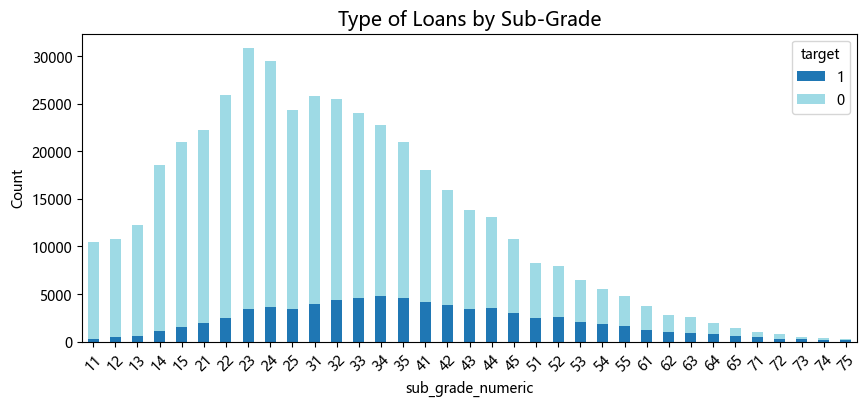

In [ ]:
import matplotlib.pyplot as plt

fig, ax2 = plt.subplots(figsize=(10, 4))

order = sorted(df_train_3["sub_grade_numeric"].dropna().unique())

loans_by_grade = (
    df_train_3.groupby(["sub_grade_numeric", "target"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(order)
)

# Put target=1 at the bottom of the stack
loans_by_grade = loans_by_grade[[1, 0]]  # if columns are int 1 and 0
# If columns are strings:
# loans_by_grade = loans_by_grade[["1", "0"]]

loans_by_grade.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    grid=False,
    rot=45,
    colormap="tab20",
)
ax2.set_title("Type of Loans by Sub-Grade", fontsize=14)
ax2.set_xlabel("sub_grade_numeric")
ax2.set_ylabel("Count")
ax2.legend(title="target")

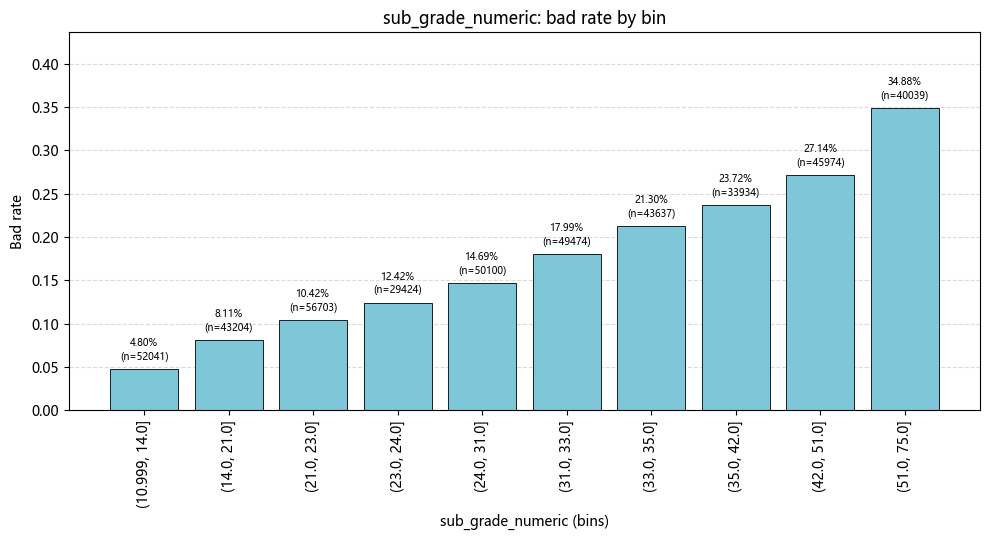

In [ ]:
plot_bad_rate_by_bin(df_train_3, "sub_grade_numeric", target="target", bins=10, method="quantile",show=True)

In [ ]:
df_train_3.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'total_rec_int', 'last_pymnt_d',
       'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths',
       'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl',
       'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl',
       'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_b

## Issue_d earliest_cr_line

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\1735543446.py:95: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d[date_col] = pd.to_datetime(d[date_col], errors="coerce")


     issue_d  issue_year issue_quarter issue_month
0 2014-12-01        2014        2014Q4     2014-12
1 2014-12-01        2014        2014Q4     2014-12
2 2014-12-01        2014        2014Q4     2014-12
3 2014-12-01        2014        2014Q4     2014-12
4 2014-12-01        2014        2014Q4     2014-12


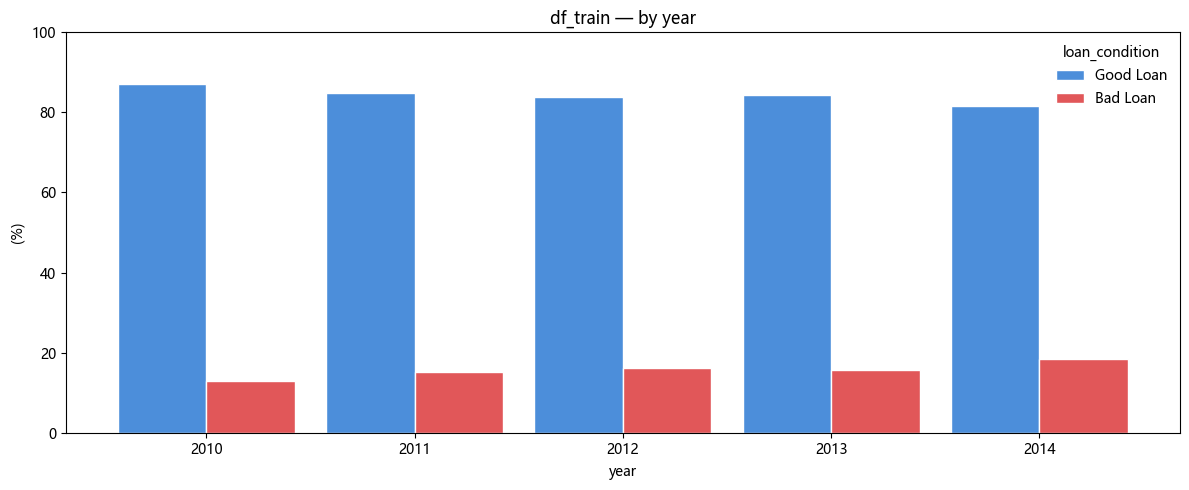

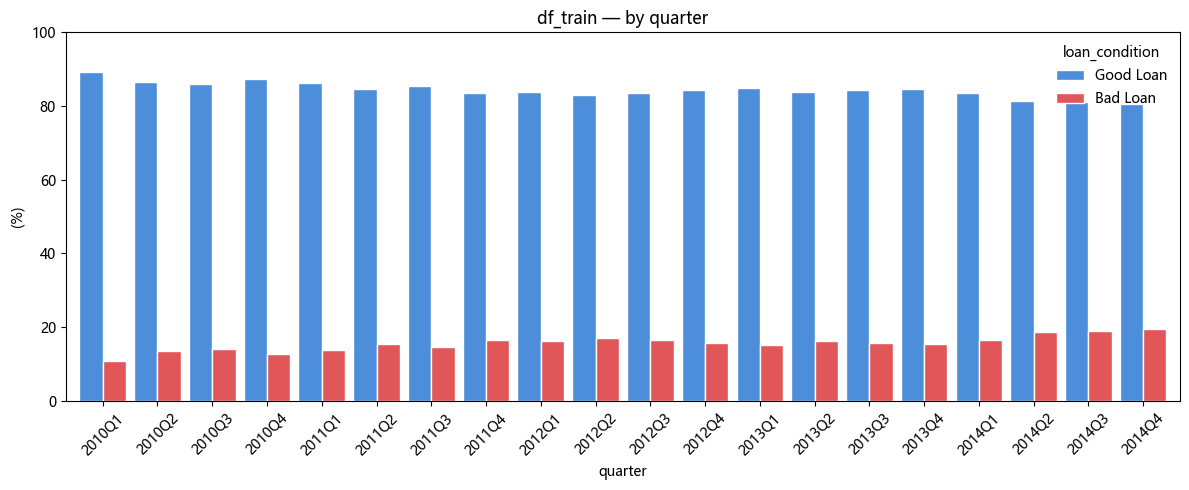

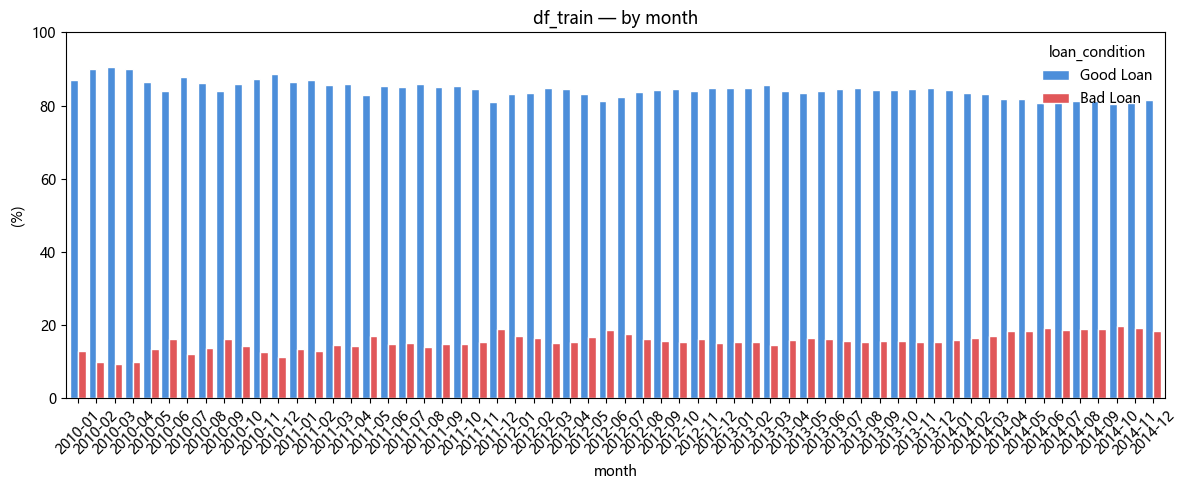

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def plot_good_bad_grouped_pct(df, date_col="issue_d", by="year", title=""):
    """
    Grouped bar chart:
    For each year / quarter / month, two side-by-side bars:
    - Good Loan (target=0)
    - Bad Loan (target=1)

    Percentages are **within each time period**: share of good vs bad among rows in that period
    (each period's two bars sum to 100%).

    Parameters
    ----------
    df : DataFrame
    date_col : str
        Date column name (default issue_d).
    by : str
        One of "year", "quarter", "month".
    title : str
        Plot title.
    """
    d = df.copy()
    d["_dt"] = pd.to_datetime(d[date_col], errors="coerce")
    d = d.dropna(subset=["_dt"])

    if by == "year":
        d["_p"] = d["_dt"].dt.year.astype(str)
        xlab = "year"
        rot = 0

    elif by == "quarter":
        d["_p"] = d["_dt"].dt.to_period("Q").astype(str)
        xlab = "quarter"
        rot = 45

    elif by == "month":
        d["_p"] = d["_dt"].dt.to_period("M").astype(str)
        xlab = "month"
        rot = 45

    else:
        raise ValueError("by must be 'year', 'quarter', or 'month'")

    ct = d.groupby(["_p", "target"], observed=False).size().unstack(fill_value=0)

    for c in [0, 1]:
        if c not in ct.columns:
            ct[c] = 0

    ct = ct[[0, 1]]

    pct = ct.div(ct.sum(axis=1), axis=0) * 100

    pct = pct.rename(columns={0: "Good Loan", 1: "Bad Loan"})

    color_map = {
        "Good Loan": "#4C8EDA",
        "Bad Loan": "#E15759",
    }
    colors = [color_map[c] for c in pct.columns]

    ax = pct.plot(
        kind="bar",
        figsize=(12, 5),
        width=0.85,
        color=colors,
        edgecolor="white",
        rot=rot,
    )

    ax.set_xlabel(xlab)
    ax.set_ylabel("(%)")
    ax.set_title(title or f"Good vs Bad by {xlab}")
    ax.legend(title="loan_condition", frameon=False)

    ax.set_ylim(0, 100)

    ax.grid(False)
    plt.tight_layout()
    plt.show()


def add_issue_time_parts(df, date_col="issue_d"):
    """
    Add columns derived from issue date:
    - issue_year
    - issue_quarter
    - issue_month
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")

    d["issue_year"] = d[date_col].dt.year
    d["issue_quarter"] = d[date_col].dt.to_period("Q").astype(str)
    d["issue_month"] = d[date_col].dt.to_period("M").astype(str)

    return d


# =========================
# 1. Split issue_d into parts
# =========================
df_train_plot = add_issue_time_parts(df_train, date_col="issue_d")

print(df_train_plot[["issue_d", "issue_year", "issue_quarter", "issue_month"]].head())


# =========================
# 2. Plots by year / quarter / month
# =========================
plot_good_bad_grouped_pct(
    df_train_plot,
    date_col="issue_d",
    by="year",
    title="df_train — by year",
)

plot_good_bad_grouped_pct(
    df_train_plot,
    date_col="issue_d",
    by="quarter",
    title="df_train — by quarter",
)

plot_good_bad_grouped_pct(
    df_train_plot,
    date_col="issue_d",
    by="month",
    title="df_train — by month",
)

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\3416975532.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d[date_col] = pd.to_datetime(d[date_col], errors="coerce")


     issue_d  issue_year  issue_quarter  issue_month
0 2014-12-01        2014              4           12
1 2014-12-01        2014              4           12
2 2014-12-01        2014              4           12
3 2014-12-01        2014              4           12
4 2014-12-01        2014              4           12


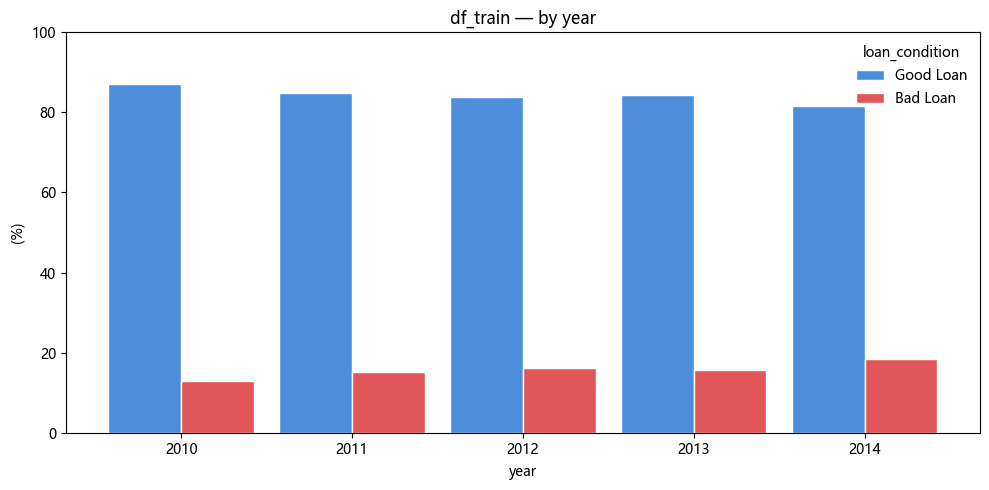

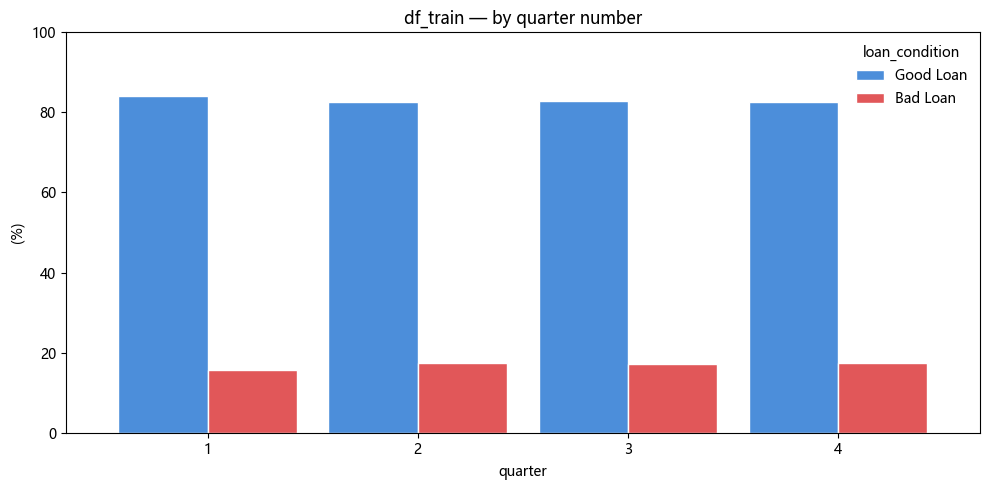

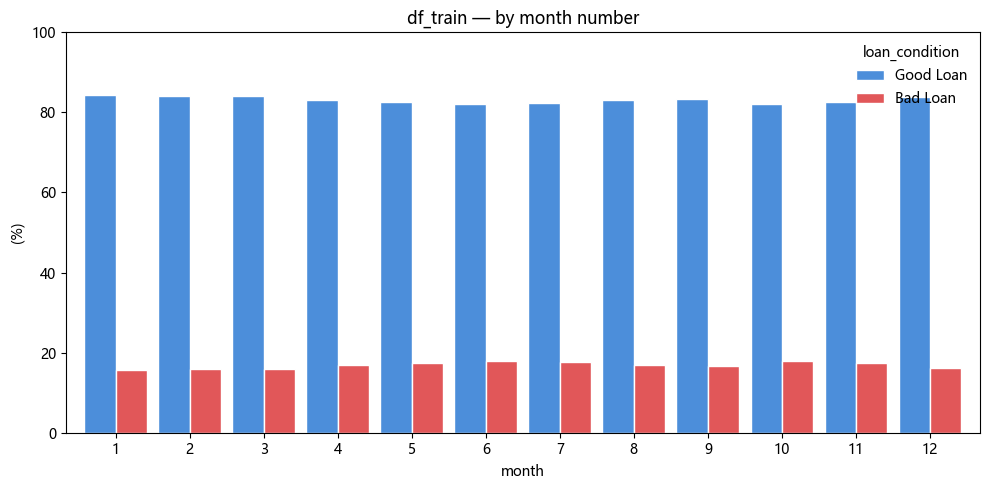

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 1. Split issue_d
# =========================
def split_issue_d(df, date_col="issue_d"):
    """
    Add issue_year, issue_quarter (1–4), issue_month (1–12) from parsed issue date.
    """
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")

    d["issue_year"] = d[date_col].dt.year.astype("Int64")

    d["issue_quarter"] = d[date_col].dt.quarter.astype("Int64")

    d["issue_month"] = d[date_col].dt.month.astype("Int64")

    return d


# =========================
# 2. Good vs bad share by grouping column
# =========================
def plot_good_bad_grouped_pct_by_col(df, group_col, title=""):
    """
    Grouped bars: within each `group_col` level, percentage of Good (0) vs Bad (1).
    Rows sum to 100% per group.
    """
    d = df.copy()
    d = d.dropna(subset=[group_col, "target"])

    ct = d.groupby([group_col, "target"], observed=False).size().unstack(fill_value=0)

    for c in [0, 1]:
        if c not in ct.columns:
            ct[c] = 0

    ct = ct[[0, 1]]

    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    pct = pct.rename(columns={0: "Good Loan", 1: "Bad Loan"})

    if group_col in ["issue_year", "issue_quarter", "issue_month"]:
        pct = pct.sort_index()
    rot = 0 if group_col in ["issue_year", "issue_quarter", "issue_month"] else 45

    if group_col == "issue_year":
        xlab = "year"
    elif group_col == "issue_quarter":
        xlab = "quarter"
    elif group_col == "issue_month":
        xlab = "month"
    else:
        xlab = group_col

    ax = pct.plot(
        kind="bar",
        figsize=(10, 5),
        width=0.85,
        color=["#4C8EDA", "#E15759"],
        edgecolor="white",
        rot=rot,
    )

    ax.set_xlabel(xlab)
    ax.set_ylabel("(%)")
    ax.set_title(title or f"Good vs Bad by {xlab}")
    ax.legend(title="loan_condition", frameon=False)
    ax.set_ylim(0, 100)
    ax.grid(False)

    plt.tight_layout()
    plt.show()


# =========================
# 3. Build split columns
# =========================
df_train_plot = split_issue_d(df_train, date_col="issue_d")

print(df_train_plot[["issue_d", "issue_year", "issue_quarter", "issue_month"]].head())


# =========================
# 4. Plots
# =========================

# By calendar year: 2010, 2011, ...
plot_good_bad_grouped_pct_by_col(
    df_train_plot,
    group_col="issue_year",
    title="df_train — by year",
)

# By quarter number: 1–4 (pooled across years)
plot_good_bad_grouped_pct_by_col(
    df_train_plot,
    group_col="issue_quarter",
    title="df_train — by quarter number",
)

# By month number: 1–12 (pooled across years)
plot_good_bad_grouped_pct_by_col(
    df_train_plot,
    group_col="issue_month",
    title="df_train — by month number",
)

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\3416975532.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d[date_col] = pd.to_datetime(d[date_col], errors="coerce")


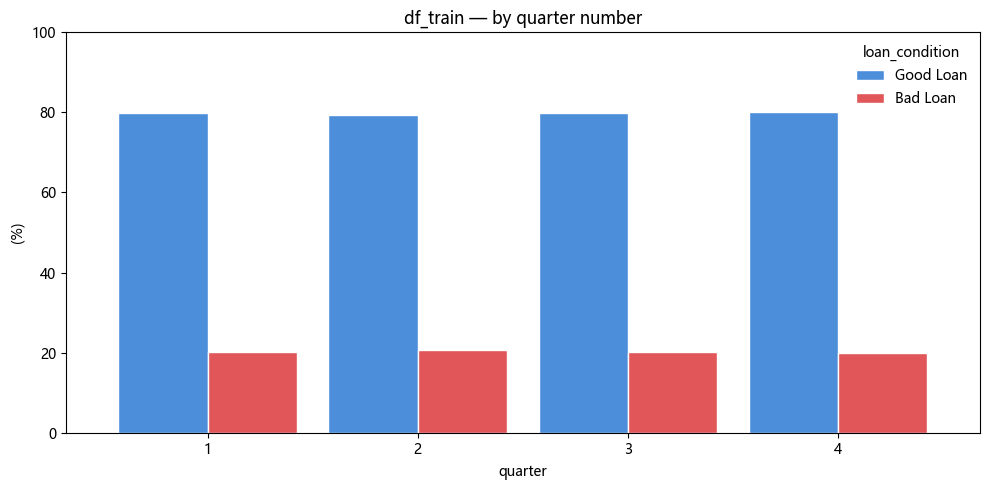

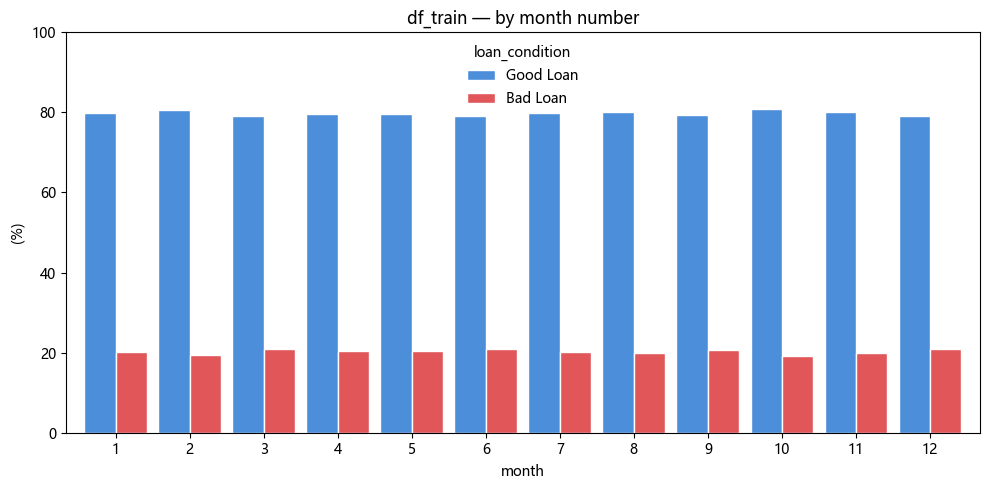

In [ ]:
df_test_plot = split_issue_d(df_test, date_col="issue_d")

# By Quater：1 / 2 / 3 / 4
plot_good_bad_grouped_pct_by_col(
    df_test_plot,
    group_col="issue_quarter",
    title="df_train — by quarter number"
)

# By Month：1 / 2 / 3 / ... / 12
plot_good_bad_grouped_pct_by_col(
    df_test_plot,
    group_col="issue_month",
    title="df_train — by month number"
)

In [ ]:
# bad loan has nothing to do with issue_d

In [ ]:
import pandas as pd
import numpy as np

def add_credit_history_length(
    df,
    issue_col="issue_d",
    earliest_col="earliest_cr_line",
):
    df = df.copy()
    issue = pd.to_datetime(df[issue_col], errors="coerce")
    earliest = pd.to_datetime(df[earliest_col], errors="coerce")

    delta = issue - earliest  # Timedelta

    df["credit_history_length_days"] = delta.dt.days

    df["credit_history_length_mths"] = delta.dt.days / 30.4375

    return df


df_train_3 = add_credit_history_length(df_train_3)
df_test_3 = add_credit_history_length(df_test_3)

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\3129366819.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  issue = pd.to_datetime(df[issue_col], errors="coerce")
C:\Users\59907\AppData\Local\Temp\ipykernel_43420\3129366819.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  earliest = pd.to_datetime(df[earliest_col], errors="coerce")


In [ ]:
# df_test_3 = add_credit_history_length(df_test_3)

In [ ]:
df_train_3["credit_history_length_days"]

0         9222
1         7427
2         8065
3         4505
4         4140
          ... 
444525    8492
444526    2922
444527    4139
444528    3805
444529    3256
Name: credit_history_length_days, Length: 444530, dtype: int64

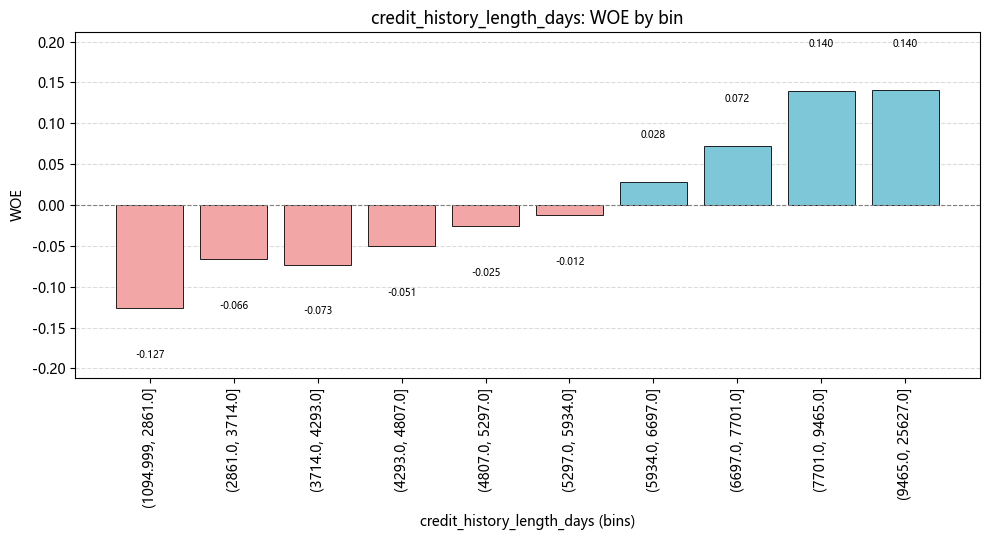

In [ ]:
plot_woe_by_bin(df_train_3, "credit_history_length_days", target="target", bins=10, method="quantile")

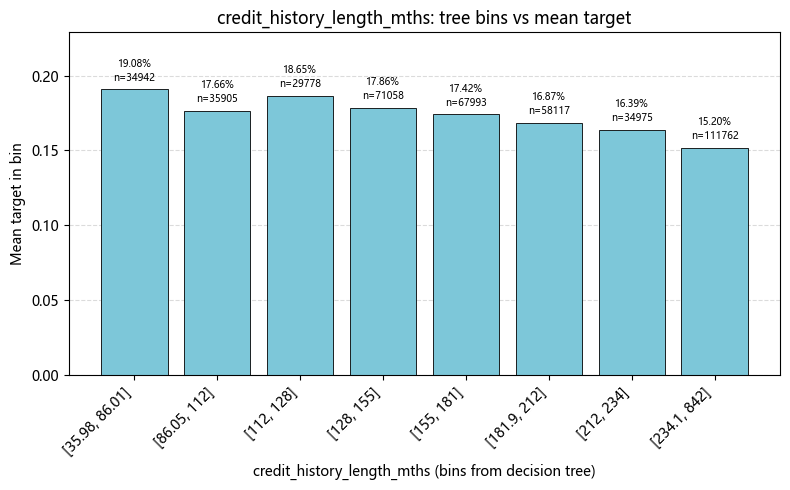

{'clf': DecisionTreeClassifier(max_leaf_nodes=8, min_samples_leaf=22227, random_state=0),
 'is_numeric': True,
 'uniques': None,
 'col': 'credit_history_length_mths',
 'target': 'target'}

In [ ]:
plot_decision_tree_bins(df_train_3, "credit_history_length_mths")

In [ ]:
# credit_history_length_days can be converted to woe and be used in model

## addr_state

In [ ]:
df_train_3['addr_state'].unique()

array(['CA', 'VA', 'NJ', 'AZ', 'MO', 'NY', 'WA', 'MN', 'FL', 'MD', 'MI',
       'KY', 'IN', 'TX', 'CO', 'AL', 'HI', 'NM', 'OH', 'NC', 'PA', 'UT',
       'LA', 'GA', 'MS', 'CT', 'KS', 'IL', 'MA', 'NH', 'SD', 'WV', 'TN',
       'SC', 'OR', 'OK', 'NV', 'AR', 'VT', 'DC', 'RI', 'WI', 'MT', 'WY',
       'AK', 'DE', 'IA', 'ME', 'ID', 'NE'], dtype=object)

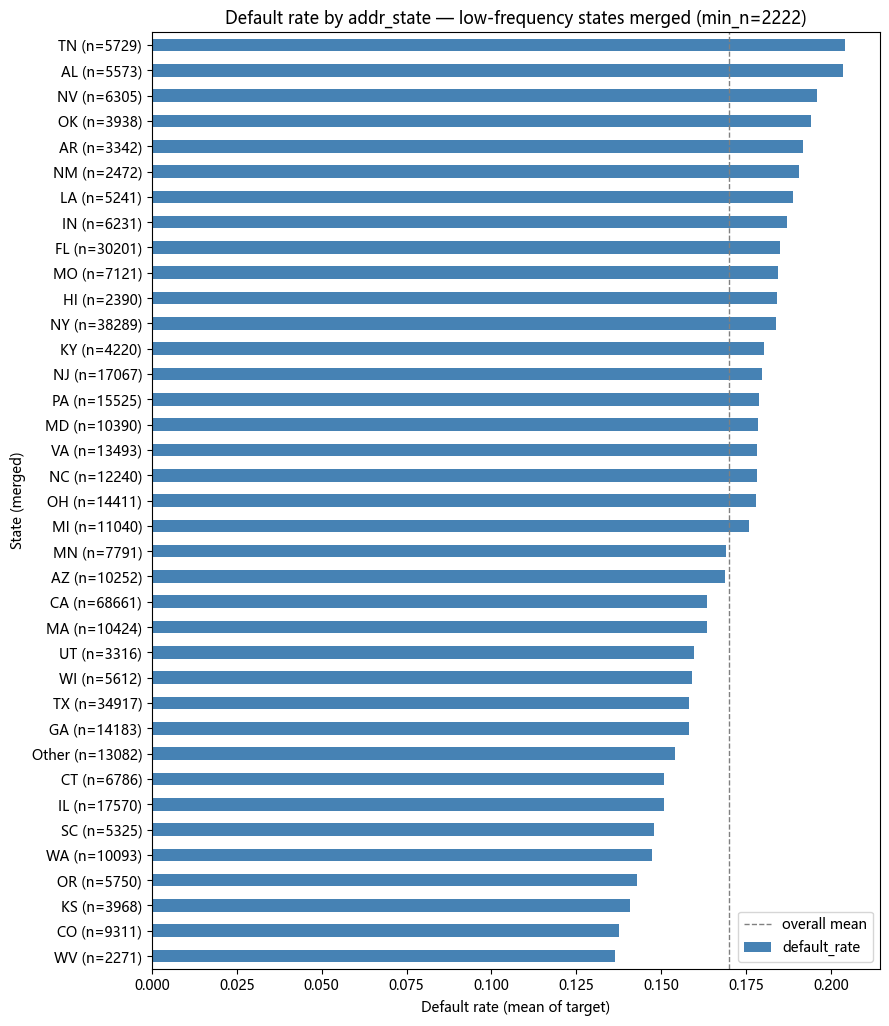

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

s = df_train_3.dropna(subset=["addr_state"]).copy()

# samples for each state
cnt = s["addr_state"].value_counts()
min_n = max(100, int(0.005 * len(s)))  # at least 100 and no less than 0.5%

keep_states = cnt[cnt >= min_n].index
s["addr_state_g"] = s["addr_state"].where(s["addr_state"].isin(keep_states), other="Other")

agg = (
    s.groupby("addr_state_g", observed=False)["target"]
    .agg(default_rate="mean", count="count")
    .sort_values("default_rate", ascending=True)
)

plt.figure(figsize=(9, max(5, len(agg) * 0.28)))
ax = agg["default_rate"].plot(kind="barh", color="steelblue", edgecolor="none")
ax.set_yticklabels([f"{idx} (n={int(agg.loc[idx, 'count'])})" for idx in agg.index])

plt.xlabel("Default rate (mean of target)")
plt.ylabel("State (merged)")
plt.title(f"Default rate by addr_state — low-frequency states merged (min_n={min_n})")
plt.axvline(s["target"].mean(), color="gray", linestyle="--", linewidth=1, label="overall mean")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



In [ ]:
#
import pandas as pd

min_n = max(100, int(0.005 * len(s)))  ## samples for each state  at least 100 and no less than 0.5%


cnt = df_train_3["addr_state"].value_counts()
keep_states = cnt[cnt >= min_n].index

def map_addr_modified(series: pd.Series) -> pd.Series:
    s = series.astype("object")
    return s.where(s.isin(keep_states), other="Other")

df_train_3 = df_train_3.copy()
df_train_3["addr_modified"] = map_addr_modified(df_train_3["addr_state"])

df_test_3 = df_test_3.copy()
df_test_3["addr_modified"] = map_addr_modified(df_test_3["addr_state"])

In [ ]:
# check addr using region

In [ ]:
import pandas as pd
import numpy as np
state_to_region = {
        # Northeast
        "CT": "Northeast", "ME": "Northeast", "MA": "Northeast",
        "NH": "Northeast", "RI": "Northeast", "VT": "Northeast",
        "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

        # Midwest
        "IL": "Midwest", "IN": "Midwest", "MI": "Midwest",
        "OH": "Midwest", "WI": "Midwest", "IA": "Midwest",
        "KS": "Midwest", "MN": "Midwest", "MO": "Midwest",
        "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",

        # South
        "DE": "South", "FL": "South", "GA": "South",
        "MD": "South", "NC": "South", "SC": "South",
        "VA": "South", "DC": "South", "WV": "South",
        "AL": "South", "KY": "South", "MS": "South",
        "TN": "South", "AR": "South", "LA": "South",
        "OK": "South", "TX": "South",

        # West
        "AZ": "West", "CO": "West", "ID": "West",
        "MT": "West", "NV": "West", "NM": "West",
        "UT": "West", "WY": "West", "AK": "West",
        "CA": "West", "HI": "West", "OR": "West",
        "WA": "West"
    }
def add_region_from_state(df, state_col="addr_state"):
    d = df.copy()
    d[state_col] = d[state_col].astype(str).str.strip().str.upper()

    d["region"] = d[state_col].map(state_to_region)

    d["region"] = d["region"].fillna("Unknown")

    return d

In [ ]:
df_train_3 = add_region_from_state(df_train_3, state_col="addr_state")

In [ ]:
# try to use region to replace addr_state
df_train_3 = df_train_3.copy()
df_train_3["region"] = df_train_3["addr_state"].map(state_to_region)

In [ ]:
df_test_3["region"] = df_test_3["addr_state"].map(state_to_region)

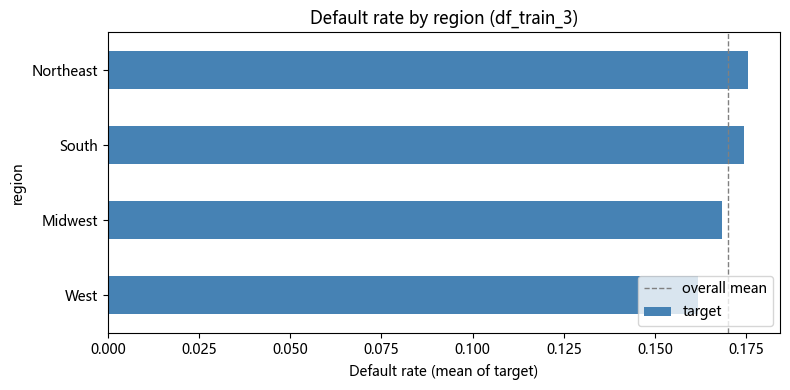

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

s = df_train_3.dropna(subset=["region"])
by_region = (
    s.groupby("region", observed=False)["target"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, max(4, len(by_region) * 0.35)))
by_region.plot(kind="barh", color="steelblue", edgecolor="none")
plt.xlabel("Default rate (mean of target)")
plt.ylabel("region")
plt.title("Default rate by region (df_train_3)")
plt.axvline(s["target"].mean(), color="gray", linestyle="--", linewidth=1, label="overall mean")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
# Summary we can try to use addr_modified to replace addr_state

In [ ]:
# df_train_3.columns

## purpose

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\1323793070.py:68: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cnt = pd.pivot_table(
C:\Users\59907\AppData\Local\Temp\ipykernel_43420\1323793070.py:77: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  bad_rate = pd.pivot_table(


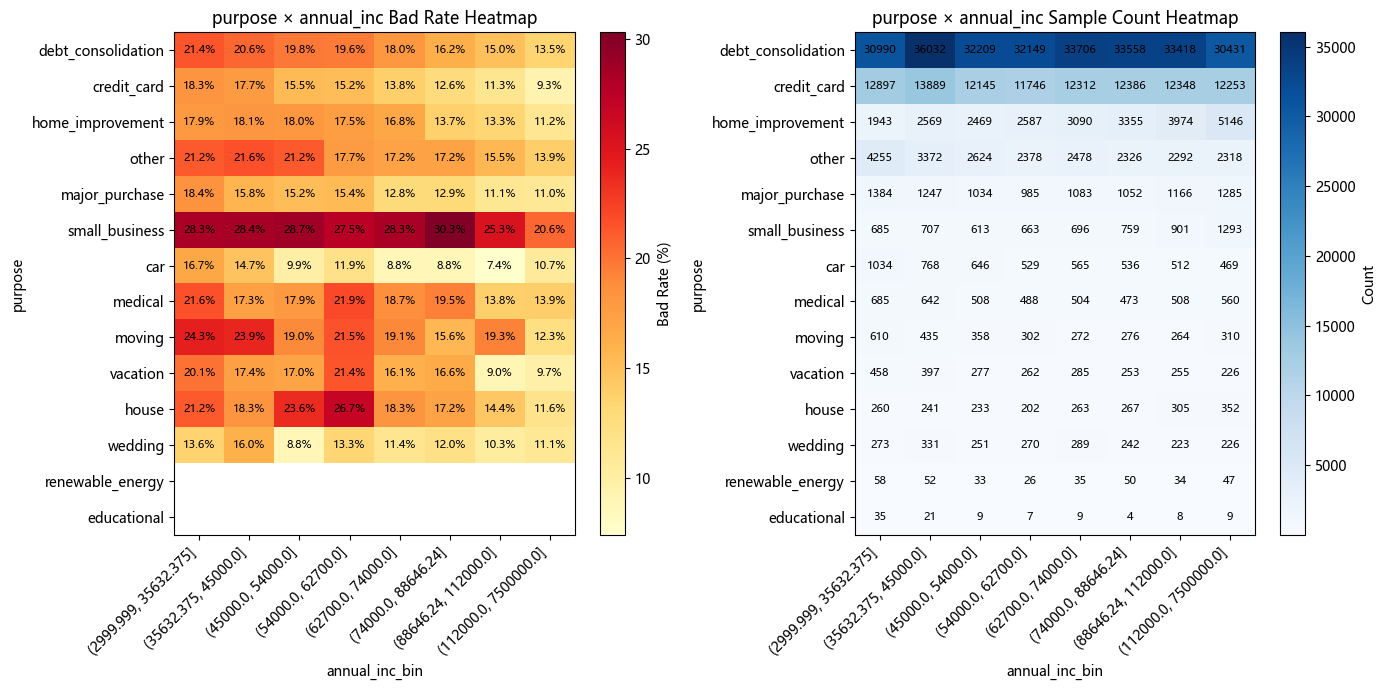

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\1323793070.py:68: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cnt = pd.pivot_table(
C:\Users\59907\AppData\Local\Temp\ipykernel_43420\1323793070.py:77: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  bad_rate = pd.pivot_table(


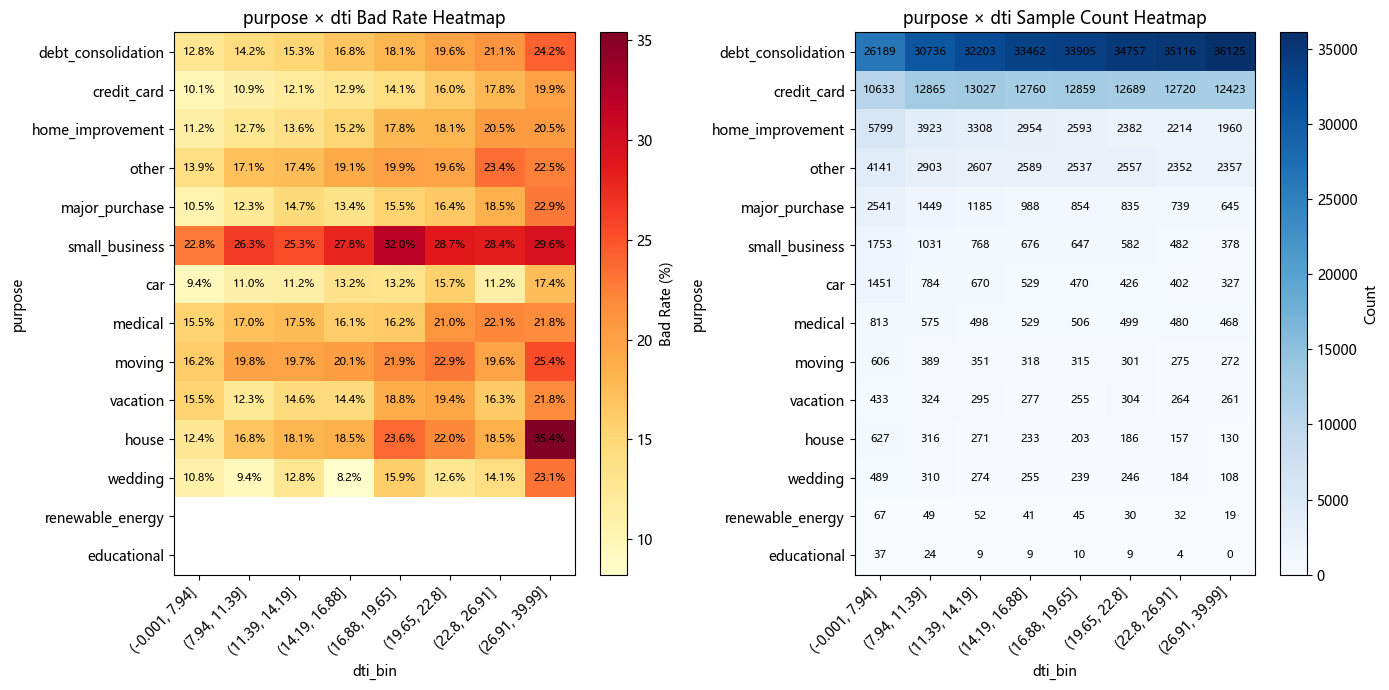

C:\Users\59907\AppData\Local\Temp\ipykernel_43420\1323793070.py:68: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cnt = pd.pivot_table(
C:\Users\59907\AppData\Local\Temp\ipykernel_43420\1323793070.py:77: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  bad_rate = pd.pivot_table(


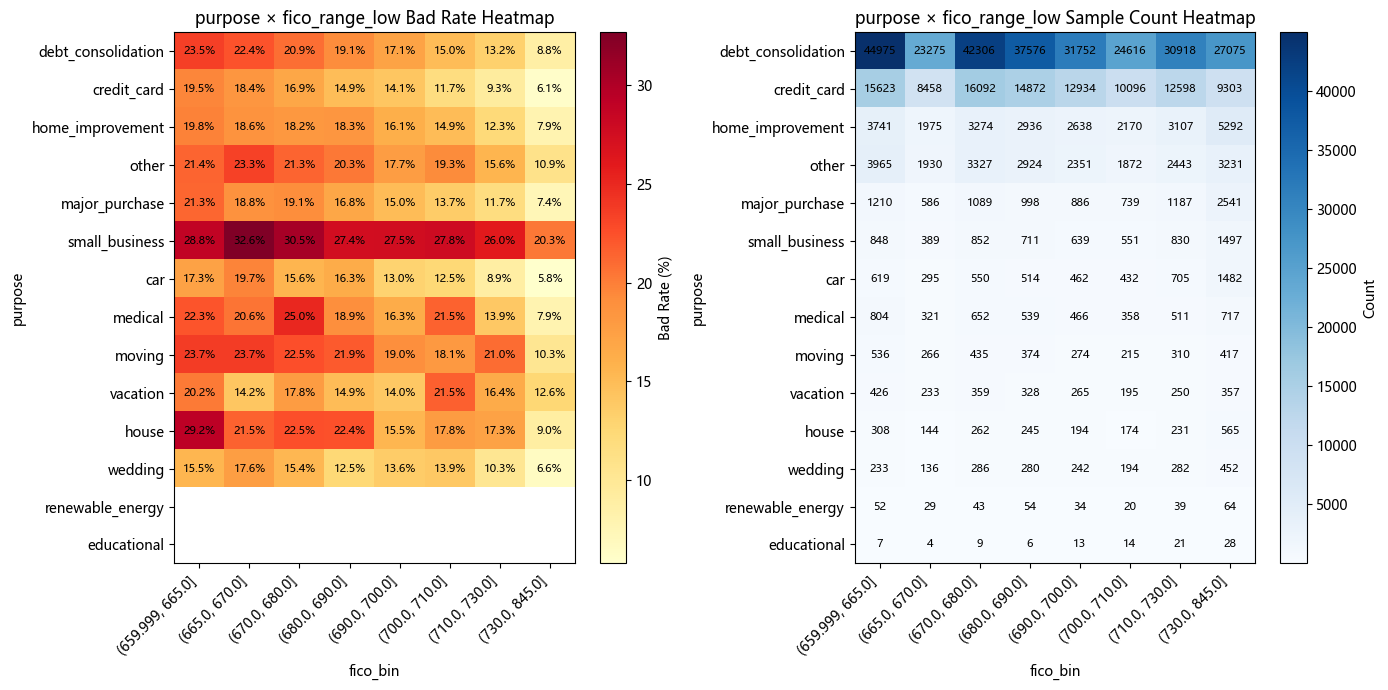

Figures saved to: ./interaction_plots


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


# =========================
# 0. Merge rare categories into Other
# =========================
def merge_rare_categories(
    df,
    col,
    min_count=100,
    other_label="Other",
):
    """Merge categories with count < min_count into other_label."""
    d = df.copy()
    vc = d[col].value_counts()
    keep = vc[vc >= min_count].index
    d[col] = d[col].astype("object").where(d[col].isin(keep), other=other_label)
    return d


# =========================
# 1. Bin continuous variables (default 8 bins)
# =========================
def add_binned_features(
    df,
    annual_inc_col="annual_inc",
    dti_col="dti",
    fico_col="fico_range_low",
    n_bins=8,
):
    d = df.copy()

    for name, col in [
        ("annual_inc_bin", annual_inc_col),
        ("dti_bin", dti_col),
        ("fico_bin", fico_col),
    ]:
        s = d[col]
        try:
            d[name] = pd.qcut(s, q=n_bins, duplicates="drop")
        except Exception:
            d[name] = pd.cut(s, bins=min(n_bins, max(2, s.nunique(dropna=True))))

    return d


# =========================
# 2. Plot and save heatmaps
# =========================
def plot_interaction_heatmaps(
    df,
    row_col,
    col_col,
    target_col="target",
    min_count=100,
    figsize=(14, 7),
    title_prefix="",
    save_path=None,
    bad_cmap="YlOrRd",
    cnt_cmap="Blues",
):
    d = df.copy()
    d = d.dropna(subset=[row_col, col_col, target_col])

    cnt = pd.pivot_table(
        d,
        index=row_col,
        columns=col_col,
        values=target_col,
        aggfunc="count",
        fill_value=0,
    )

    bad_rate = pd.pivot_table(
        d,
        index=row_col,
        columns=col_col,
        values=target_col,
        aggfunc="mean",
    ) * 100

    bad_rate_masked = bad_rate.mask(cnt < min_count)

    if row_col == "purpose":
        row_order = d[row_col].value_counts().index.tolist()
        cnt = cnt.reindex(row_order)
        bad_rate = bad_rate.reindex(row_order)
        bad_rate_masked = bad_rate_masked.reindex(row_order)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    im1 = axes[0].imshow(bad_rate_masked.values, aspect="auto", cmap=bad_cmap)
    axes[0].set_title(f"{title_prefix} Bad Rate Heatmap")
    axes[0].set_xlabel(col_col)
    axes[0].set_ylabel(row_col)
    axes[0].set_xticks(np.arange(len(bad_rate_masked.columns)))
    axes[0].set_xticklabels([str(c) for c in bad_rate_masked.columns], rotation=45, ha="right")
    axes[0].set_yticks(np.arange(len(bad_rate_masked.index)))
    axes[0].set_yticklabels([str(i) for i in bad_rate_masked.index])
    for i in range(bad_rate_masked.shape[0]):
        for j in range(bad_rate_masked.shape[1]):
            val = bad_rate_masked.iloc[i, j]
            if pd.notna(val):
                axes[0].text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=8, color="black")
    cbar1 = plt.colorbar(im1, ax=axes[0])
    cbar1.set_label("Bad Rate (%)")

    im2 = axes[1].imshow(cnt.values, aspect="auto", cmap=cnt_cmap)
    axes[1].set_title(f"{title_prefix} Sample Count Heatmap")
    axes[1].set_xlabel(col_col)
    axes[1].set_ylabel(row_col)
    axes[1].set_xticks(np.arange(len(cnt.columns)))
    axes[1].set_xticklabels([str(c) for c in cnt.columns], rotation=45, ha="right")
    axes[1].set_yticks(np.arange(len(cnt.index)))
    axes[1].set_yticklabels([str(i) for i in cnt.index])
    for i in range(cnt.shape[0]):
        for j in range(cnt.shape[1]):
            val = cnt.iloc[i, j]
            axes[1].text(j, i, f"{int(val)}", ha="center", va="center", fontsize=8, color="black")
    cbar2 = plt.colorbar(im2, ax=axes[1])
    cbar2.set_label("Count")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


# =========================
# 3. Prepare data
# =========================
purpose_min_count = 100  # purpose categories below this count -> Other
n_bins = 8

df_plot = df_train_3.copy()
df_plot = merge_rare_categories(df_plot, "purpose", min_count=purpose_min_count)

df_plot = add_binned_features(
    df_plot,
    annual_inc_col="annual_inc",
    dti_col="dti",
    fico_col="fico_range_low",
    n_bins=n_bins,
)


# =========================
# 4. Output directory
# =========================
output_dir = "./interaction_plots"
os.makedirs(output_dir, exist_ok=True)


# =========================
# 5–7. Three heatmaps (bad rate only if cell count >= min_count)
# =========================
plot_interaction_heatmaps(
    df=df_plot,
    row_col="purpose",
    col_col="annual_inc_bin",
    target_col="target",
    min_count=100,
    title_prefix="purpose × annual_inc",
    save_path=os.path.join(output_dir, "purpose_annual_inc_heatmap.png"),
)

plot_interaction_heatmaps(
    df=df_plot,
    row_col="purpose",
    col_col="dti_bin",
    target_col="target",
    min_count=100,
    title_prefix="purpose × dti",
    save_path=os.path.join(output_dir, "purpose_dti_heatmap.png"),
)

plot_interaction_heatmaps(
    df=df_plot,
    row_col="purpose",
    col_col="fico_bin",
    target_col="target",
    min_count=100,
    title_prefix="purpose × fico_range_low",
    save_path=os.path.join(output_dir, "purpose_fico_heatmap.png"),
)

print("Figures saved to:", output_dir)

In [ ]:
purpose = df_train_3["purpose"].dropna().unique()
print(f"Number of unique values in purpose: {len(purpose)}")
print(purpose[:10])  # show first 10 only

Number of unique values in purpose: 14
['credit_card' 'debt_consolidation' 'home_improvement' 'house' 'other'
 'medical' 'moving' 'major_purchase' 'car' 'vacation']


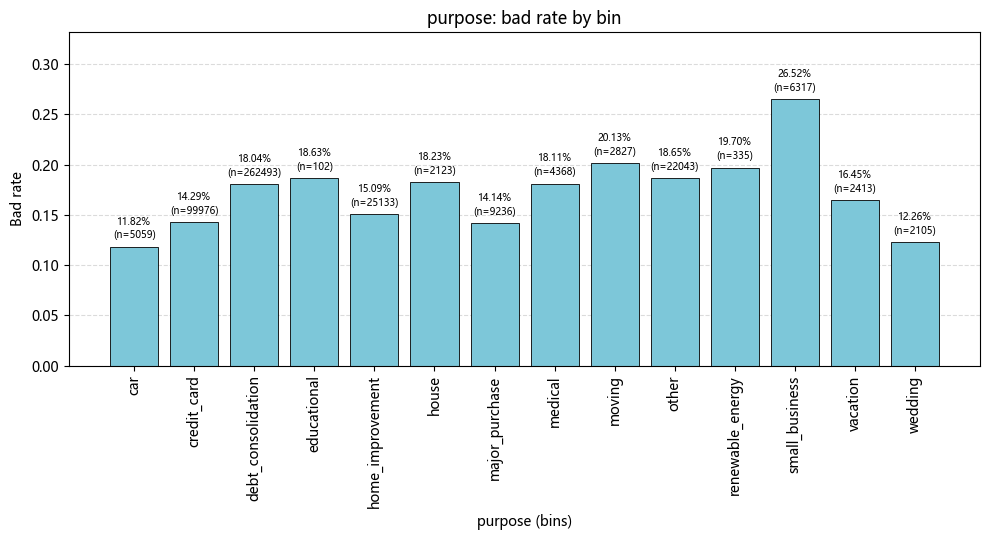

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'purpose', target='target', bins=10, method='quantile')

In [ ]:
# is_small_business_high_dti
# is_debt_consolidation_high_dti
# is_medical_high_dti

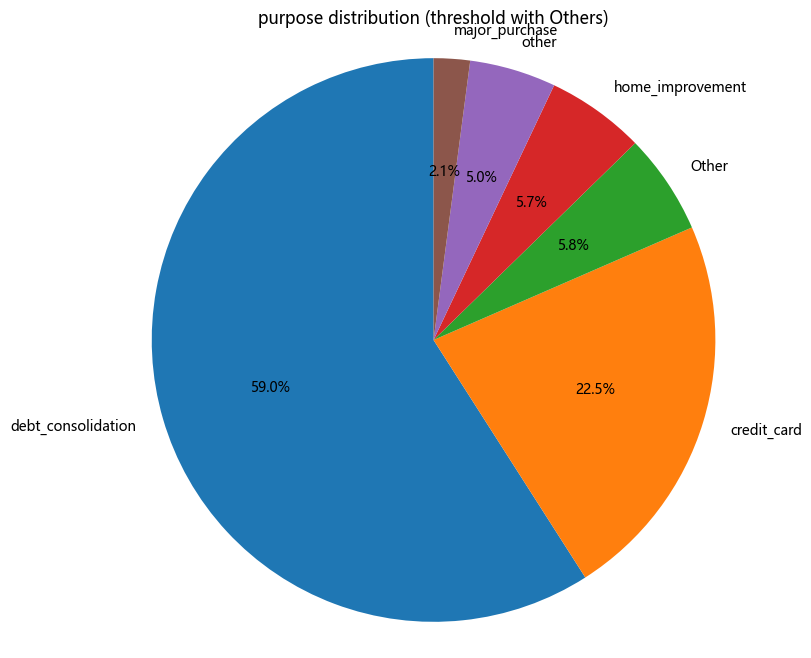

(purpose
 debt_consolidation    262493
 credit_card            99976
 Other                  25649
 home_improvement       25133
 other                  22043
 major_purchase          9236
 Name: count, dtype: int64,
 purpose
 debt_consolidation    0.590496
 credit_card           0.224903
 Other                 0.057699
 home_improvement      0.056538
 other                 0.049587
 major_purchase        0.020777
 Name: count, dtype: float64)

In [ ]:
plot_categorical_pie_with_others(
    df_train_3,
    col="purpose",
    method="threshold",
    threshold=0.02,
    others_label="Other",
    missing_label="(missing)",
    figsize=(8, 8),
    show=True,
)

In [ ]:
# For purpose only we can have a is small business


## delinq_2yrs
### Number of delinquencies in the past 2 years

In [ ]:
delinq_2yrs = df_train_3['delinq_2yrs'].dropna().unique()
print(f"📌 delinq_2yrs unique value：{len(delinq_2yrs)}")
print(delinq_2yrs[:10])

📌 delinq_2yrs unique value：24
[ 0.  1.  2.  3.  4.  6.  5. 11. 13.  9.]


In [ ]:
delinq_2yrs = df_train_3["delinq_2yrs"].dropna().unique()
print(f"Number of unique values in delinq_2yrs: {len(purpose)}")
print(delinq_2yrs[:10])  # show first 10 only

Number of unique values in delinq_2yrs: 14
[ 0.  1.  2.  3.  4.  6.  5. 11. 13.  9.]


In [ ]:
df_train_3["delinq_2yrs"]

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
444525    1.0
444526    2.0
444527    0.0
444528    0.0
444529    0.0
Name: delinq_2yrs, Length: 444530, dtype: float64

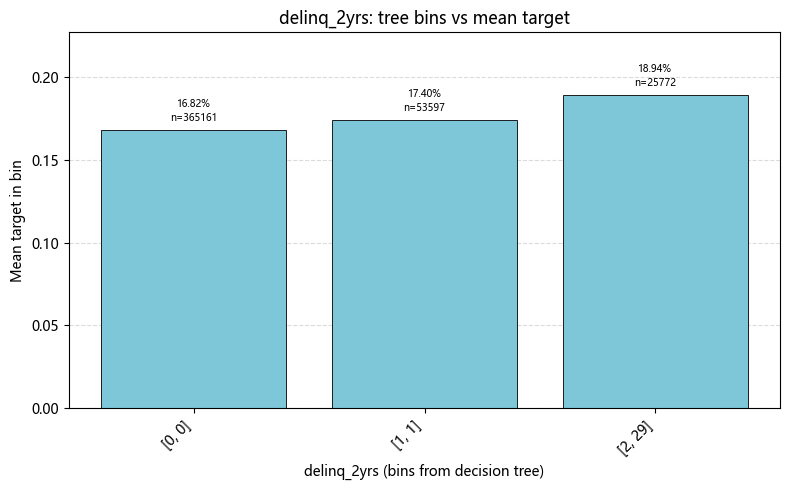

In [ ]:
plot_decision_tree_bins(df_train_3, 'delinq_2yrs', target='target')

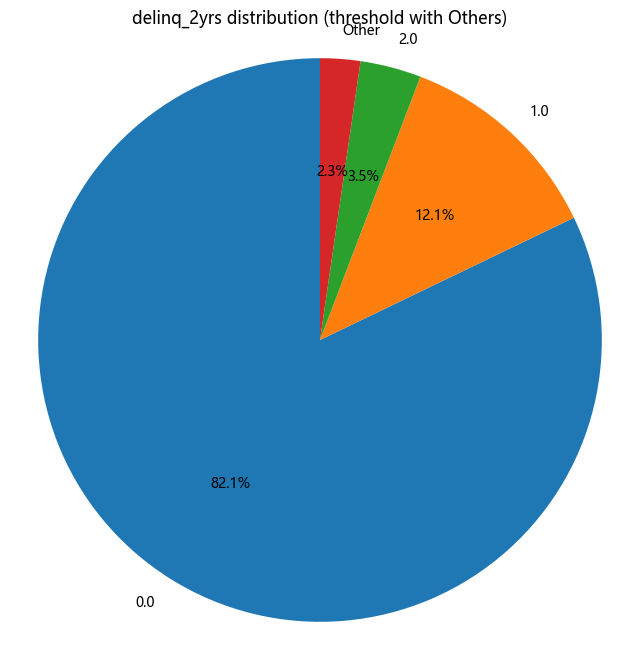

(delinq_2yrs
 0.0      365161
 1.0       53597
 2.0       15549
 Other     10223
 Name: count, dtype: int64,
 delinq_2yrs
 0.0      0.821454
 1.0      0.120570
 2.0      0.034979
 Other    0.022997
 Name: count, dtype: float64)

In [ ]:
plot_categorical_pie_with_others(
    df_train_3,
    col="delinq_2yrs",
    method="threshold",
    threshold=0.02,
    others_label="Other",
    missing_label="(missing)",
    figsize=(8, 8),
    show=True,
)

## home ownership

In [ ]:
home_ownership = df_train_3['home_ownership'].dropna().unique()
print(f"📌 home_ownership Number of unique values{len(home_ownership)}")
print(home_ownership[:10])

📌 home_ownership Number of unique values6
['MORTGAGE' 'RENT' 'OWN' 'ANY' 'OTHER' 'NONE']


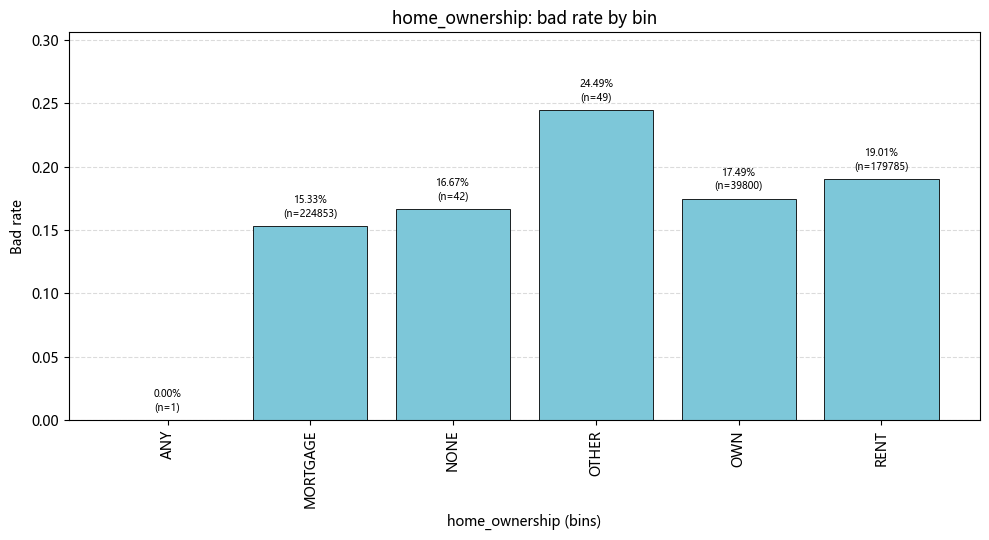

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'home_ownership', target='target', bins=24, method='quantile')

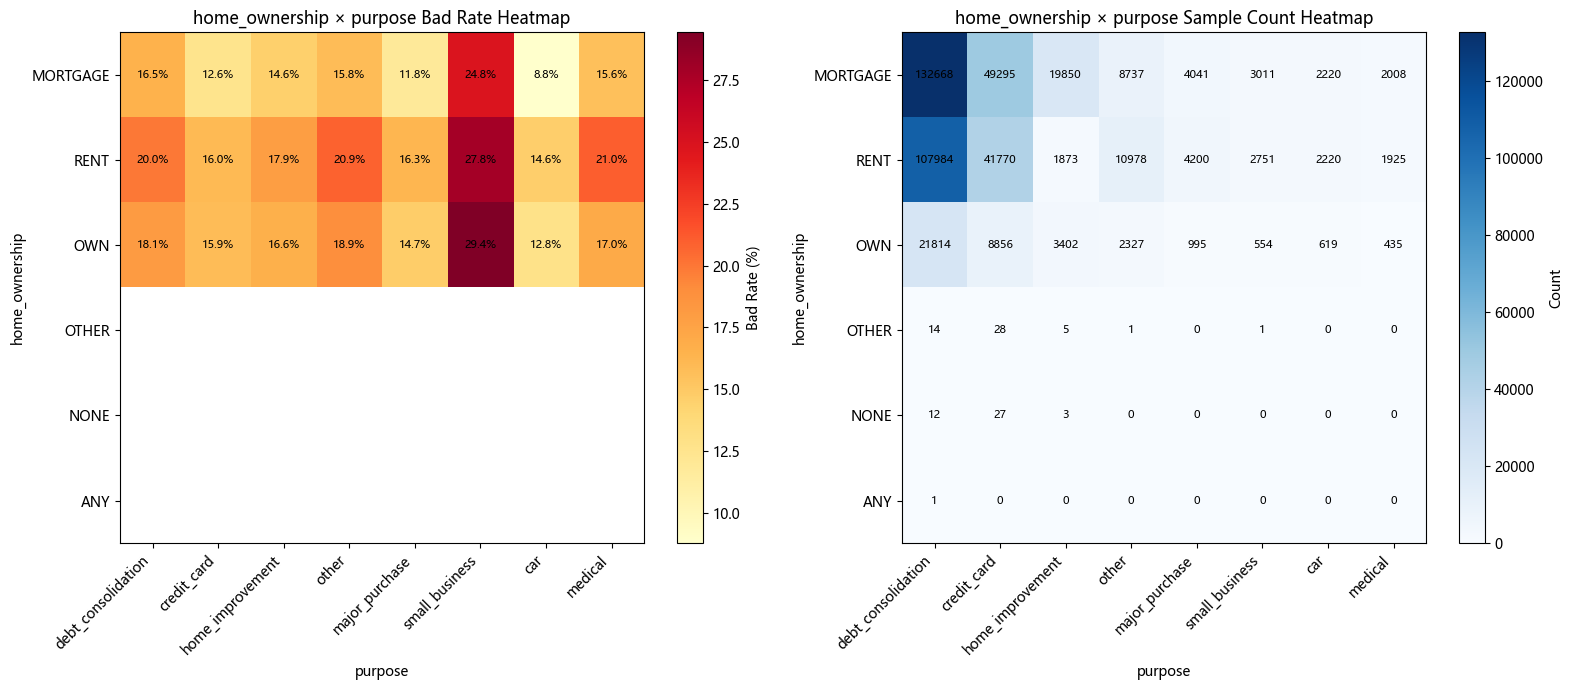

Figure saved: homeownership_purpose_heatmap.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


def plot_homeownership_purpose_heatmaps(
    df,
    home_col="home_ownership",
    purpose_col="purpose",
    target_col="target",
    min_count=100,
    top_purpose=None,
    figsize=(16, 7),
    save_path=None,
    bad_cmap="YlOrRd",
    cnt_cmap="Blues",
):
    """
    Two heatmaps: bad rate (%) and sample count for home_ownership × purpose.

    Cells with count < min_count have bad rate masked (NaN).

    top_purpose : int or None
        If set, keep only the top N purposes by frequency before pivoting.
    """
    d = df.copy()
    d = d.dropna(subset=[home_col, purpose_col, target_col])

    if top_purpose is not None:
        top_purpose_list = d[purpose_col].value_counts().head(top_purpose).index.tolist()
        d = d[d[purpose_col].isin(top_purpose_list)].copy()

    cnt = pd.pivot_table(
        d,
        index=home_col,
        columns=purpose_col,
        values=target_col,
        aggfunc="count",
        fill_value=0,
    )

    bad_rate = pd.pivot_table(
        d,
        index=home_col,
        columns=purpose_col,
        values=target_col,
        aggfunc="mean",
    ) * 100

    bad_rate_masked = bad_rate.mask(cnt < min_count)

    row_order = d[home_col].value_counts().index.tolist()
    cnt = cnt.reindex(row_order)
    bad_rate_masked = bad_rate_masked.reindex(row_order)

    col_order = d[purpose_col].value_counts().index.tolist()
    cnt = cnt[col_order]
    bad_rate_masked = bad_rate_masked[col_order]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    im1 = axes[0].imshow(bad_rate_masked.values, aspect="auto", cmap=bad_cmap)
    axes[0].set_title("home_ownership × purpose Bad Rate Heatmap")
    axes[0].set_xlabel("purpose")
    axes[0].set_ylabel("home_ownership")

    axes[0].set_xticks(np.arange(len(bad_rate_masked.columns)))
    axes[0].set_xticklabels([str(c) for c in bad_rate_masked.columns], rotation=45, ha="right")
    axes[0].set_yticks(np.arange(len(bad_rate_masked.index)))
    axes[0].set_yticklabels([str(i) for i in bad_rate_masked.index])

    for i in range(bad_rate_masked.shape[0]):
        for j in range(bad_rate_masked.shape[1]):
            val = bad_rate_masked.iloc[i, j]
            if pd.notna(val):
                axes[0].text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=8, color="black")

    cbar1 = plt.colorbar(im1, ax=axes[0])
    cbar1.set_label("Bad Rate (%)")

    im2 = axes[1].imshow(cnt.values, aspect="auto", cmap=cnt_cmap)
    axes[1].set_title("home_ownership × purpose Sample Count Heatmap")
    axes[1].set_xlabel("purpose")
    axes[1].set_ylabel("home_ownership")

    axes[1].set_xticks(np.arange(len(cnt.columns)))
    axes[1].set_xticklabels([str(c) for c in cnt.columns], rotation=45, ha="right")
    axes[1].set_yticks(np.arange(len(cnt.index)))
    axes[1].set_yticklabels([str(i) for i in cnt.index])

    for i in range(cnt.shape[0]):
        for j in range(cnt.shape[1]):
            axes[1].text(j, i, f"{int(cnt.iloc[i, j])}", ha="center", va="center", fontsize=8, color="black")

    cbar2 = plt.colorbar(im2, ax=axes[1])
    cbar2.set_label("Count")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


# Run
plot_homeownership_purpose_heatmaps(
    df=df_train_3,
    home_col="home_ownership",
    purpose_col="purpose",
    target_col="target",
    min_count=100,
    top_purpose=8,
    save_path="homeownership_purpose_heatmap.png",
)

print("Figure saved: homeownership_purpose_heatmap.png")

## verification_status

In [ ]:
verification_status = df_train_3['verification_status'].dropna().unique()
print(f"📌 verification_status Number of unique values：{len(verification_status)}")
print(verification_status[:10])


📌 verification_status Number of unique values：3
['Not Verified' 'Source Verified' 'Verified']


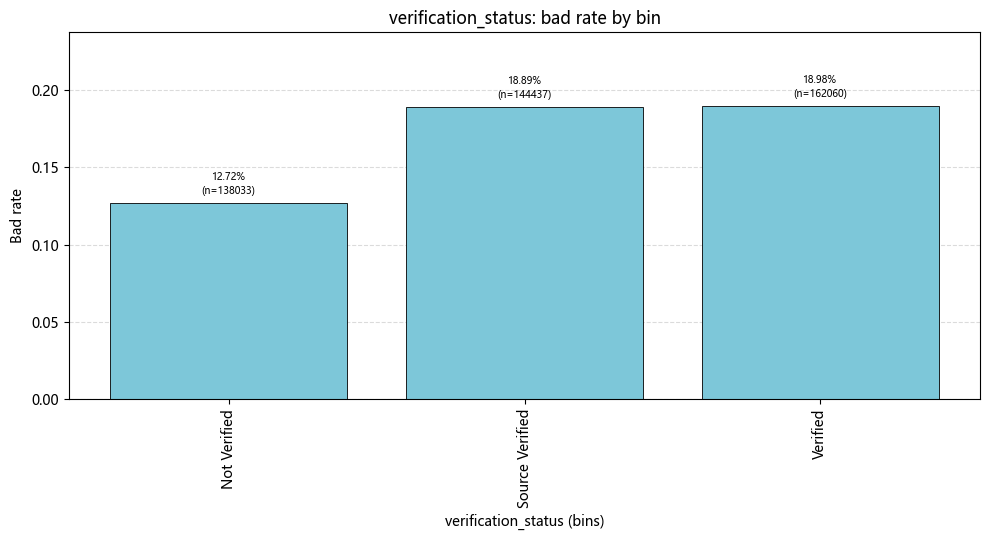

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'verification_status', target='target', bins=3, method='quantile')

In [ ]:
# df_train_3["inq_last_6mths"]

In [ ]:
inq_last_6mths = df_train_3['inq_last_6mths'].dropna().unique()
print(f"📌 inq_last_6mths Number of unique values：{len(inq_last_6mths)}")
print(inq_last_6mths[:10])

📌 inq_last_6mths Number of unique values：9
[2. 0. 1. 3. 4. 5. 6. 7. 8.]


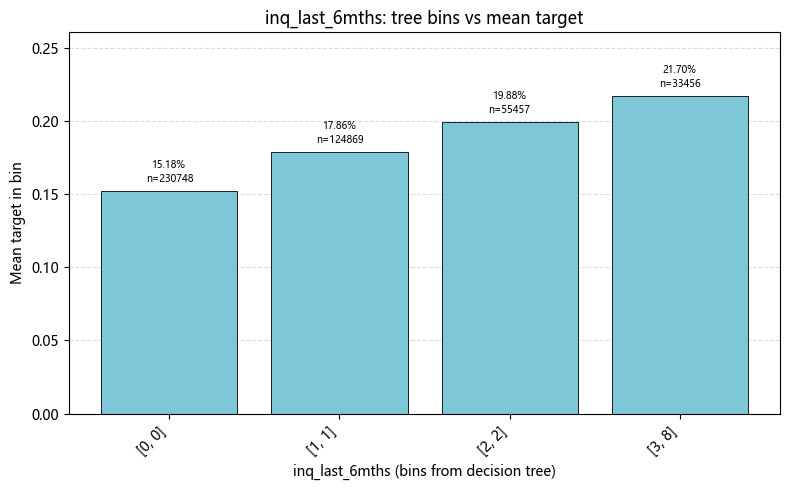

In [ ]:
plot_decision_tree_bins(df_train_3, 'inq_last_6mths', target='target')

In [ ]:
df_train_3.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'purpose', 'zip_code', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'total_rec_int',
       'last_pymnt_d', 'collections_12_mths_ex_med', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       '

## fico_range_low fico_range_high

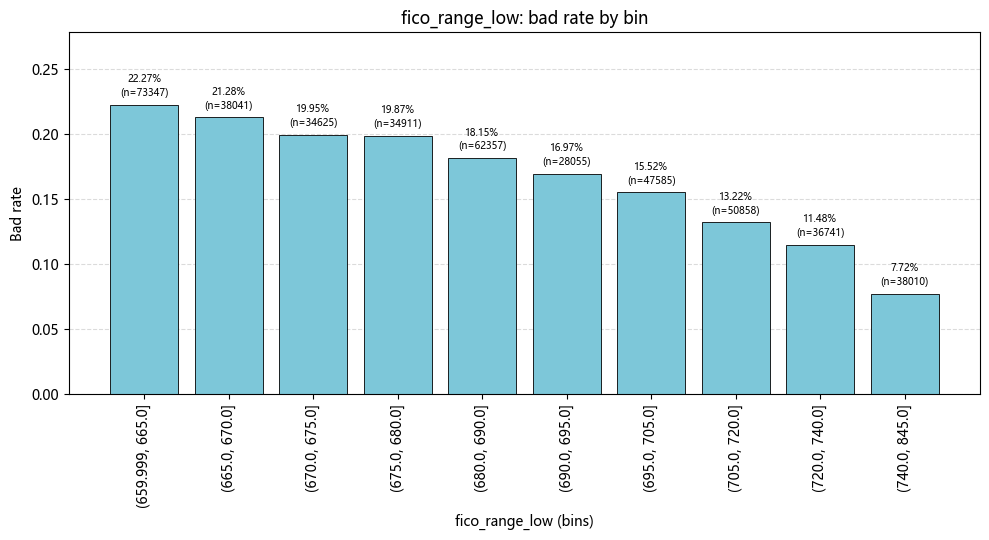

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'fico_range_low', target='target', bins=10, method='quantile')

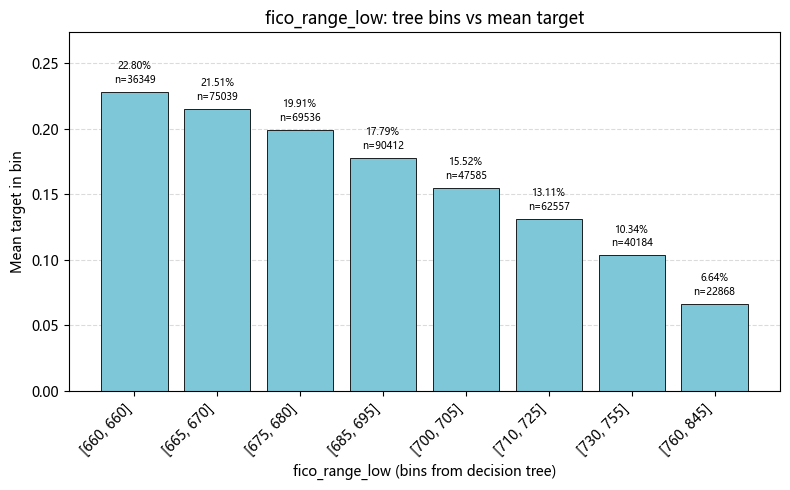

{'clf': DecisionTreeClassifier(max_leaf_nodes=8, min_samples_leaf=22227, random_state=0),
 'is_numeric': True,
 'uniques': None,
 'col': 'fico_range_low',
 'target': 'target'}

In [ ]:
plot_decision_tree_bins(df_train_3, 'fico_range_low', target='target')

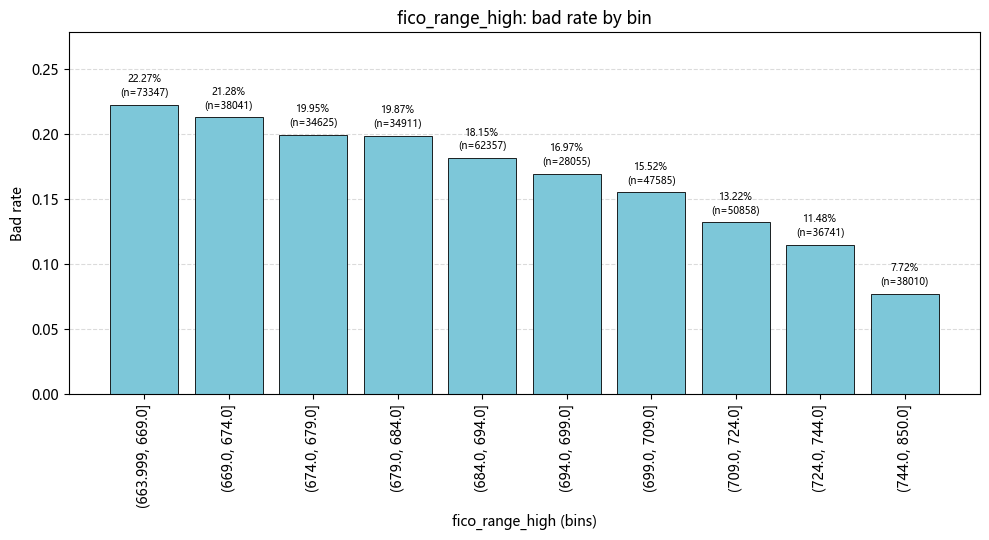

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'fico_range_high', target='target', bins=10, method='quantile')

# annual_inc


In [ ]:
# plot_bad_rate_by_bin(df_train_3, 'annual_inc', target='target', bins=9, method='quantile')
#


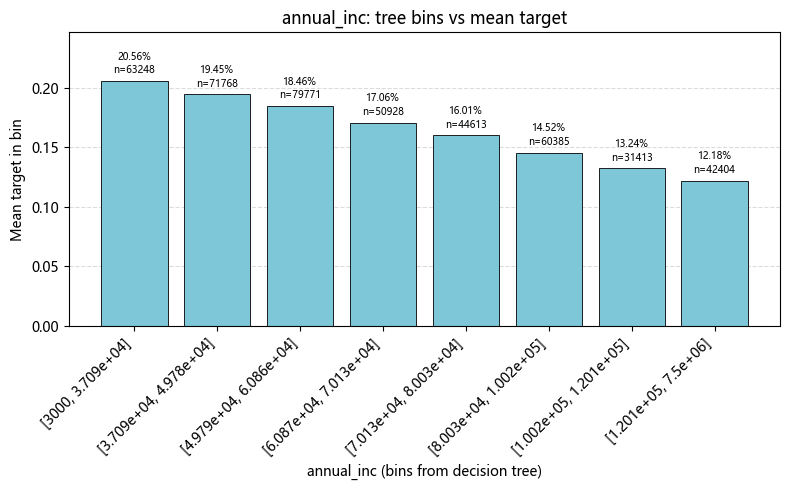

{'clf': DecisionTreeClassifier(max_leaf_nodes=8, min_samples_leaf=22227, random_state=0),
 'is_numeric': True,
 'uniques': None,
 'col': 'annual_inc',
 'target': 'target'}

In [ ]:
plot_decision_tree_bins(df_train_3, 'annual_inc', target='target')

## revol_util


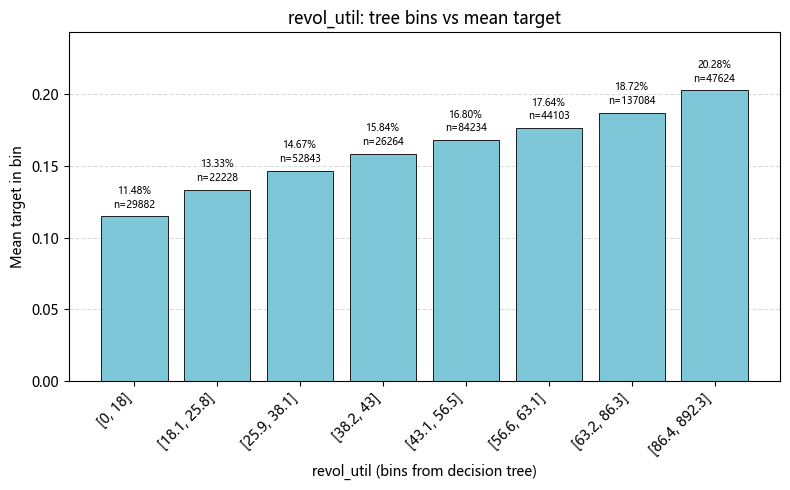

In [ ]:
plot_decision_tree_bins(df_train_3, 'revol_util', target='target')


## revol_bal


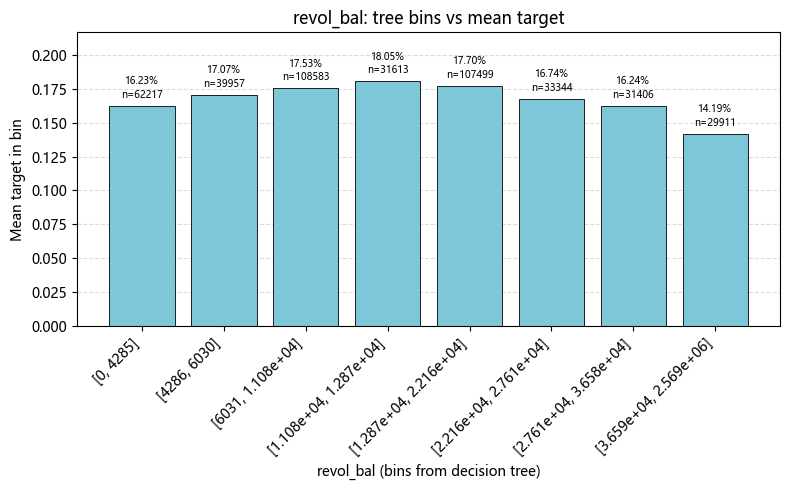

In [ ]:
plot_decision_tree_bins(df_train_3, 'revol_bal', target='target')

In [ ]:

# plot_bad_rate_by_bin(df_train_3, 'inq_last_6mths', target='target', bins=9, method='quantile')


## inq_last_6mths

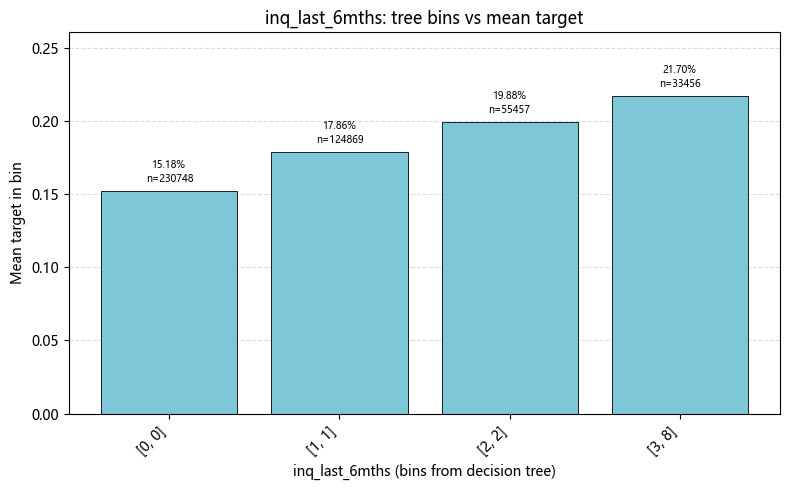

In [ ]:
plot_decision_tree_bins(df_train_3, 'inq_last_6mths', target='target')


## total_acc

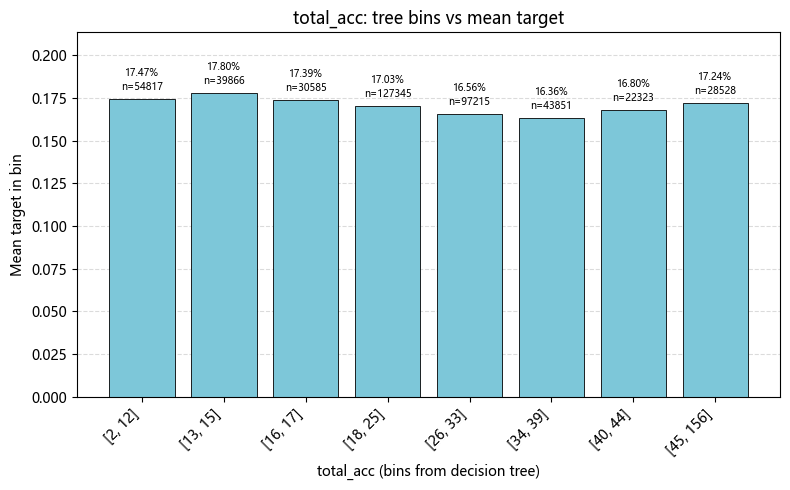

In [ ]:
plot_decision_tree_bins(df_train_3, 'total_acc', target='target')


In [ ]:
initial_list_status = df_train_3['initial_list_status'].dropna().unique()
print(f"📌 initial_list_status Number of unique values: {len(initial_list_status)}")
print(initial_list_status[:10])

📌 initial_list_status Number of unique values: 2
['w' 'f']


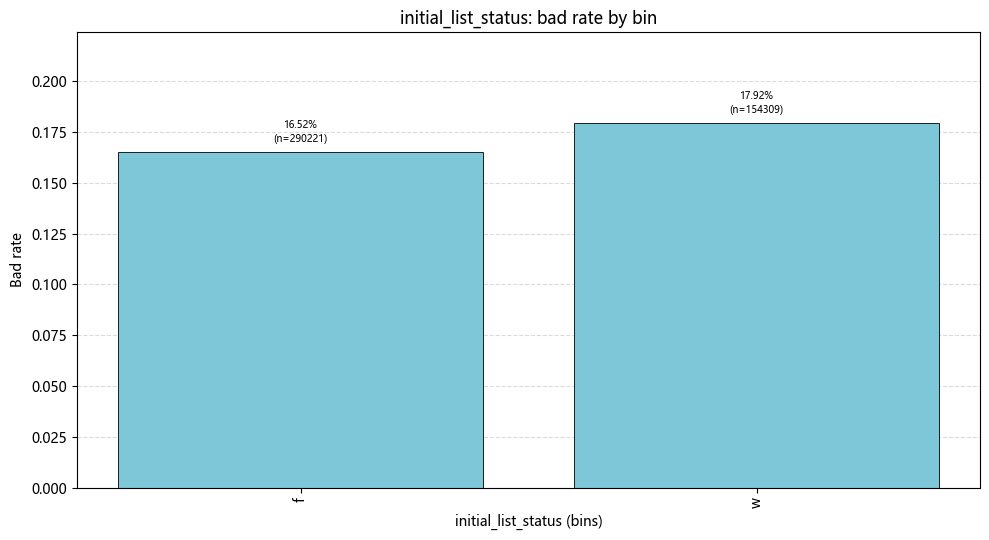

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'initial_list_status', target='target', bins=2, method='quantile')


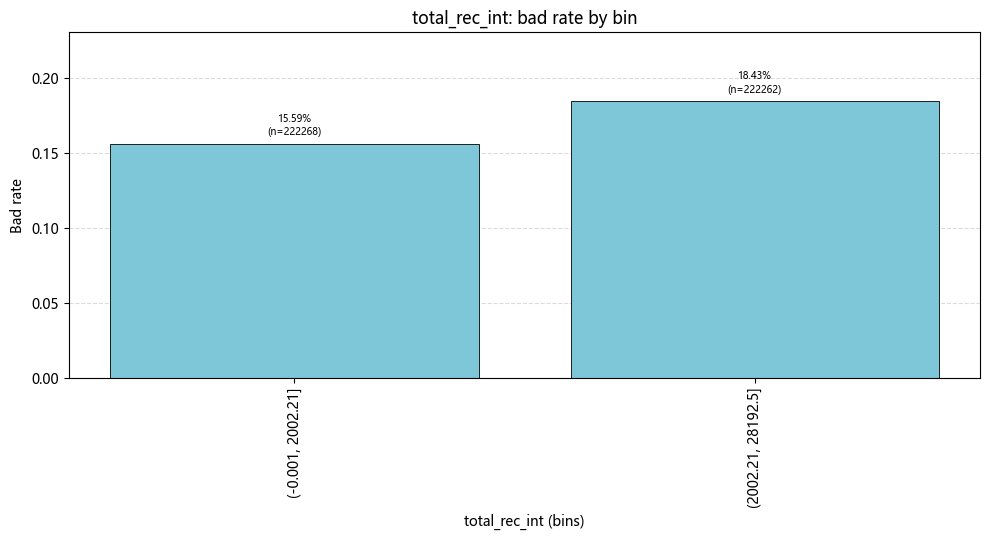

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'total_rec_int', target='target', bins=2, method='quantile')


## Open Acc

In [ ]:
open_acc = df_train_3['open_acc'].dropna().unique()
print(f"📌 open_acc Number of unique values:{len(open_acc)}")
print(open_acc[:10])

📌 open_acc Number of unique values:62
[17.  6. 12. 11. 10.  7. 14.  9.  8.  5.]


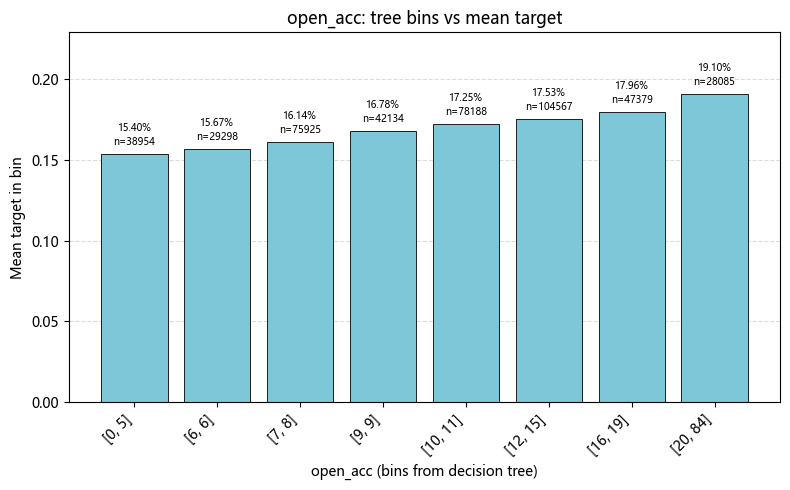

In [ ]:
plot_decision_tree_bins(df_train_3, 'open_acc', target='target')


In [ ]:
# plot_woe_by_bin(df_train_3, 'open_acc', target='target', bins=9, method='quantile')


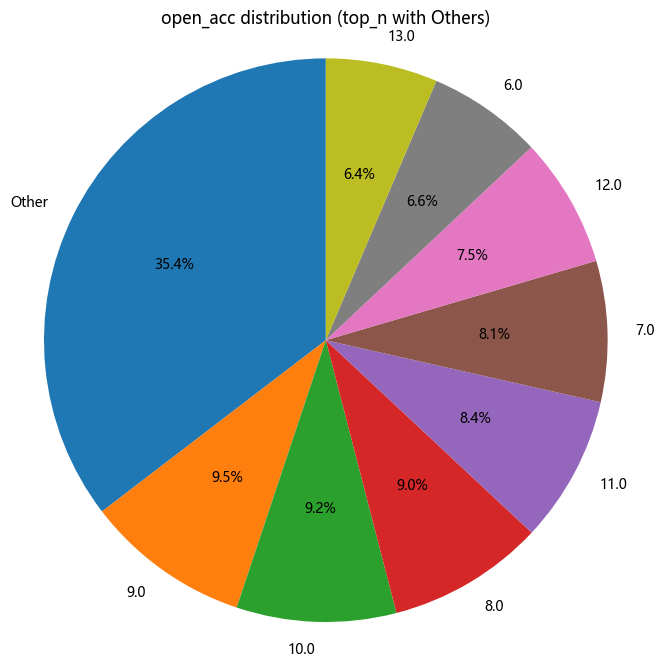

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

grouped_counts, grouped_ratio = plot_categorical_pie_with_others(
    df_train_3,
    col="open_acc",
    method="top_n",
    top_n=8,
    others_label="Other",
    missing_label="(missing)",
    figsize=(8, 8),
    autopct="%1.1f%%",
    startangle=90,
    show=True,
)

# print(grouped_counts)
# print(grouped_ratio)

## pub_rec

In [ ]:
pub_rec = df_train_3['pub_rec'].dropna().unique()
print(f"📌 pub_rec Number of unique values:{len(pub_rec)}")
print(pub_rec[:10])

📌 pub_rec Number of unique values:25
[ 0.  1.  3.  2.  4.  7.  5. 12. 18.  6.]


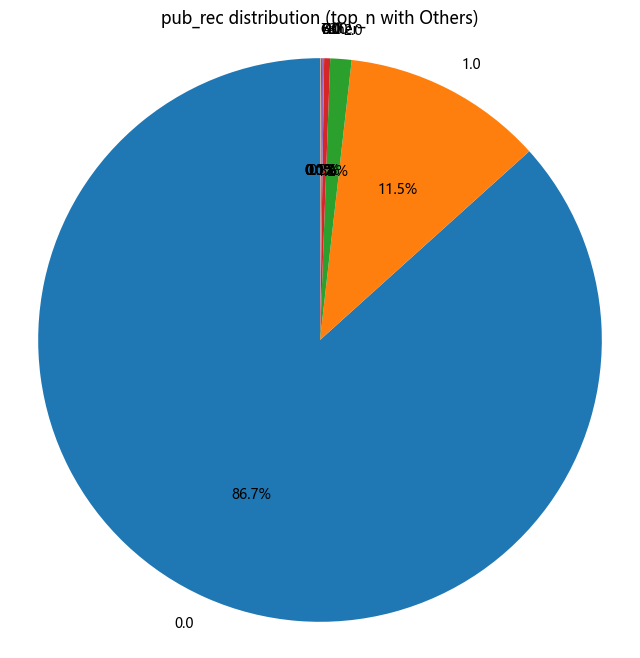

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

grouped_counts, grouped_ratio = plot_categorical_pie_with_others(
    df_train_3,
    col="pub_rec",
    method="top_n",
    top_n=8,
    others_label="Other",
    missing_label="(missing)",
    figsize=(8, 8),
    autopct="%1.1f%%",
    startangle=90,
    show=True,
)

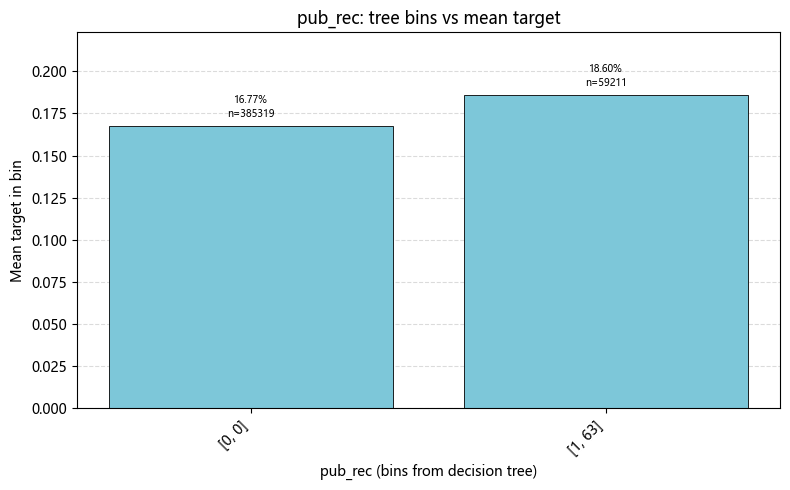

In [ ]:
plot_decision_tree_bins(df_train_3, 'pub_rec', target='target')


## emp_length_processed

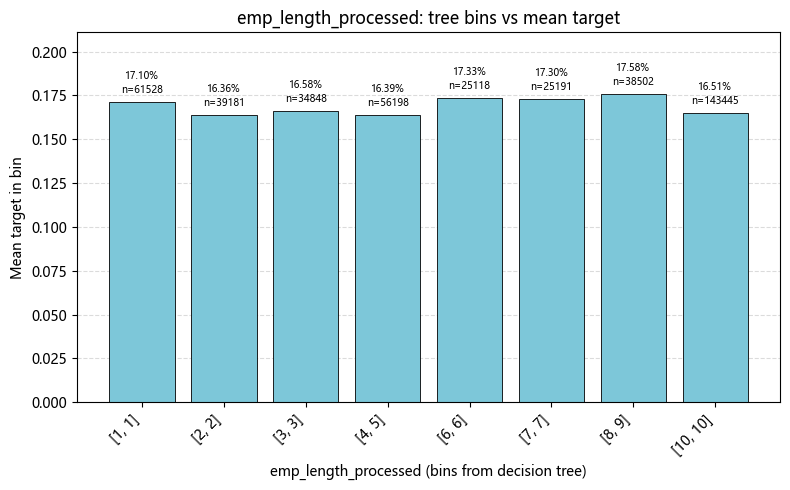

In [ ]:
plot_decision_tree_bins(df_train_3, 'emp_length_processed', target='target')


## installment

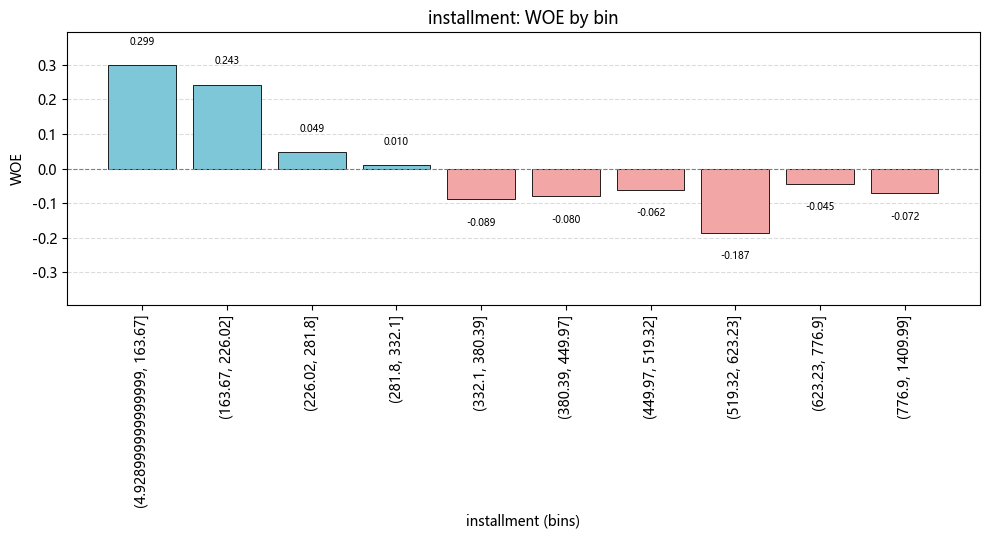

In [ ]:
plot_woe_by_bin(df_train_3, 'installment', target='target')


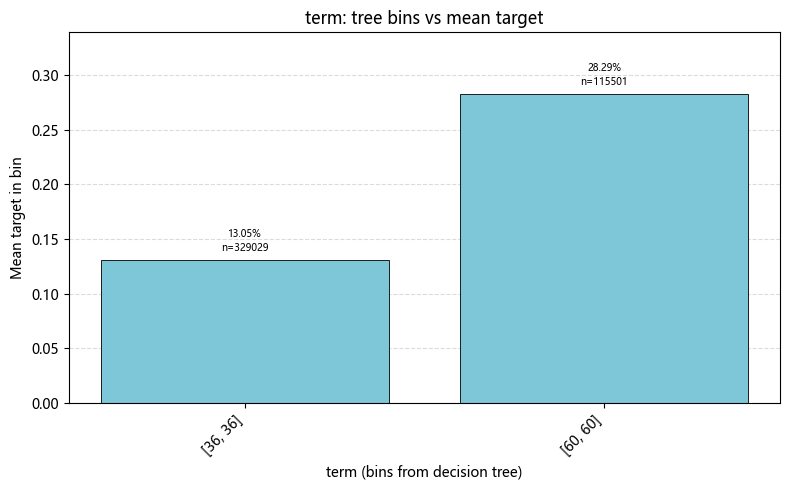

In [ ]:
plot_decision_tree_bins(df_train_3, 'term', target='target')


In [ ]:
df_train_3.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'total_rec_int', 'last_pymnt_d',
       'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths',
       'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl',
       'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl',
       'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_b

## loan_amnt

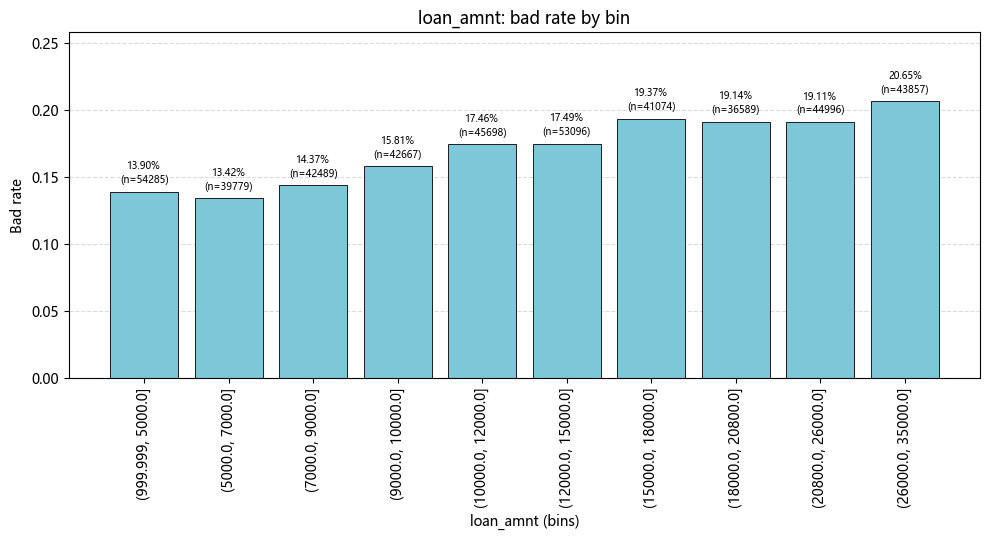

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'loan_amnt', target='target', bins=10, method='quantile')


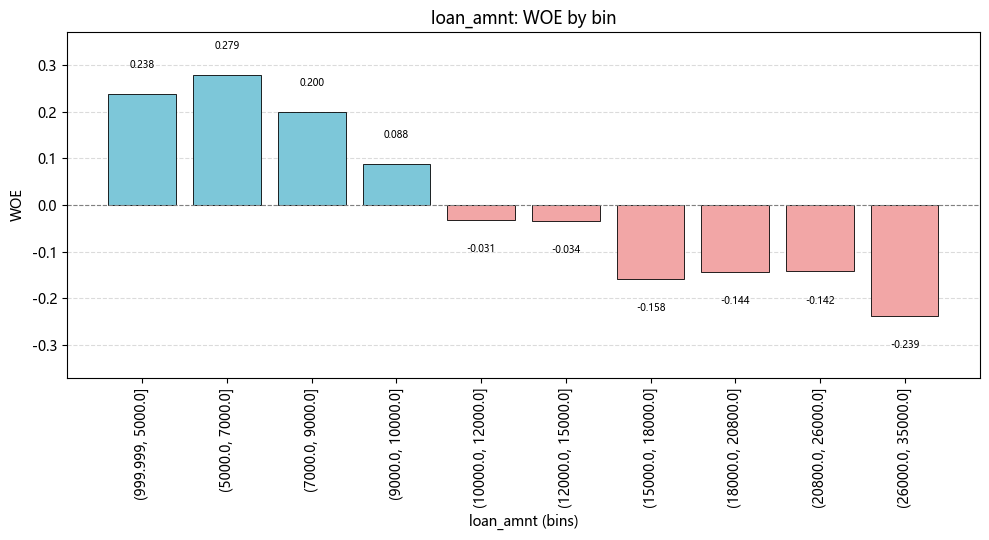

In [ ]:
plot_woe_by_bin(df_train_3, 'loan_amnt', target='target', bins=10, method='quantile')


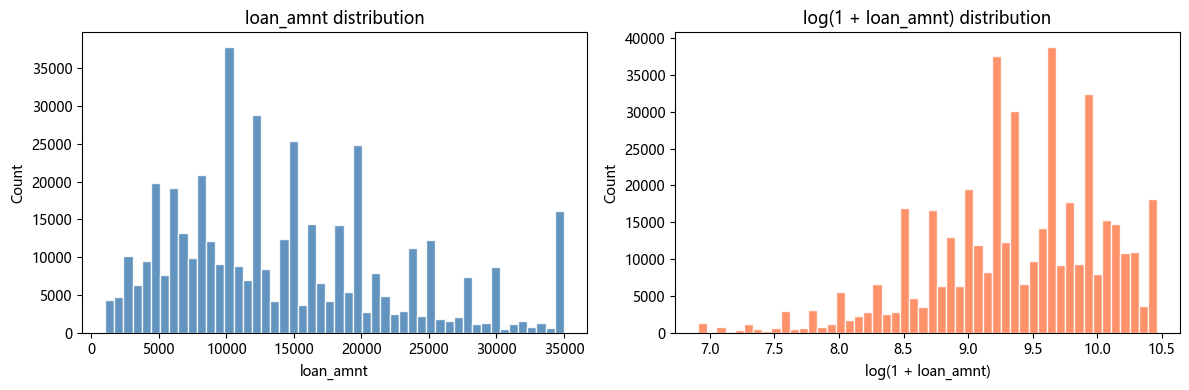

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

s = df_train_3["loan_amnt"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(s, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("loan_amnt")
axes[0].set_ylabel("Count")
axes[0].set_title("loan_amnt distribution")

axes[1].hist(np.log1p(s), bins=50, color="coral", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log(1 + loan_amnt)")
axes[1].set_ylabel("Count")
axes[1].set_title("log(1 + loan_amnt) distribution")

plt.tight_layout()
plt.show()

## int_rate

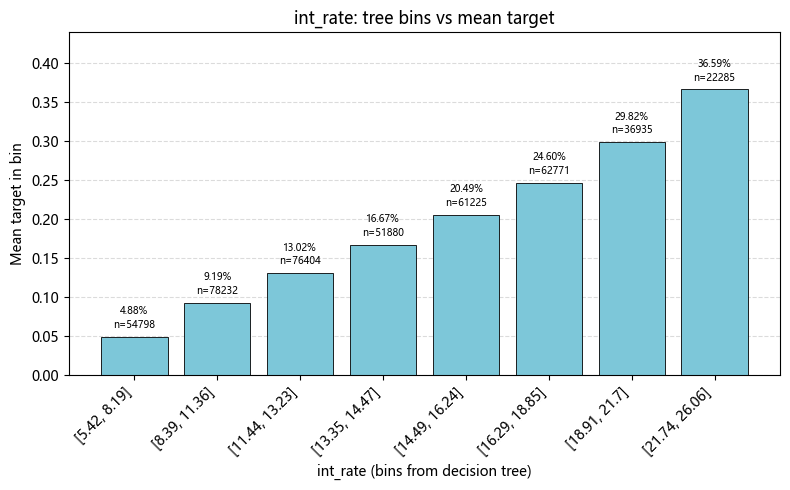

In [ ]:
plot_decision_tree_bins(df_train_3, 'int_rate', target='target')


## funded_amnt

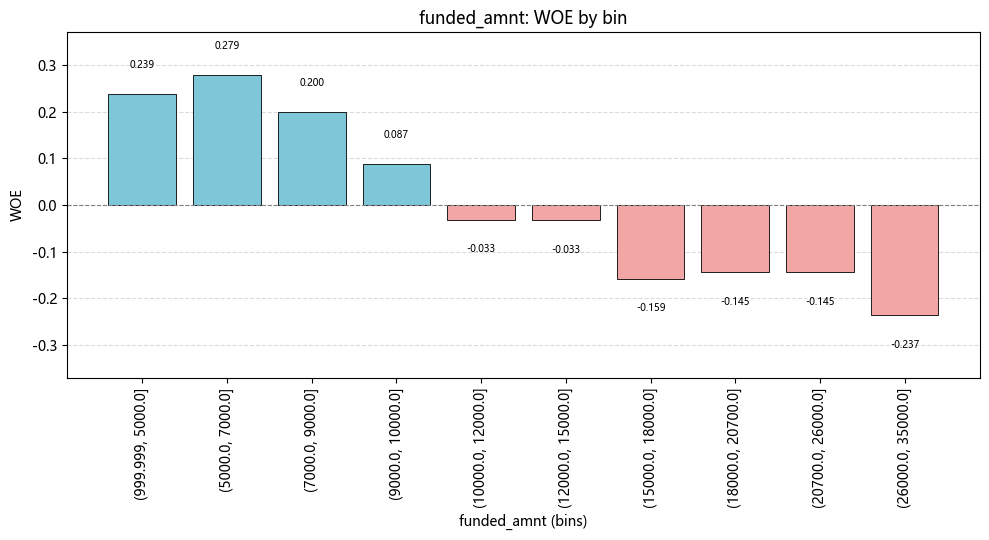

In [ ]:
plot_woe_by_bin(df_train_3, 'funded_amnt', target='target', bins=10, method='quantile')


## sub_grade_numeric

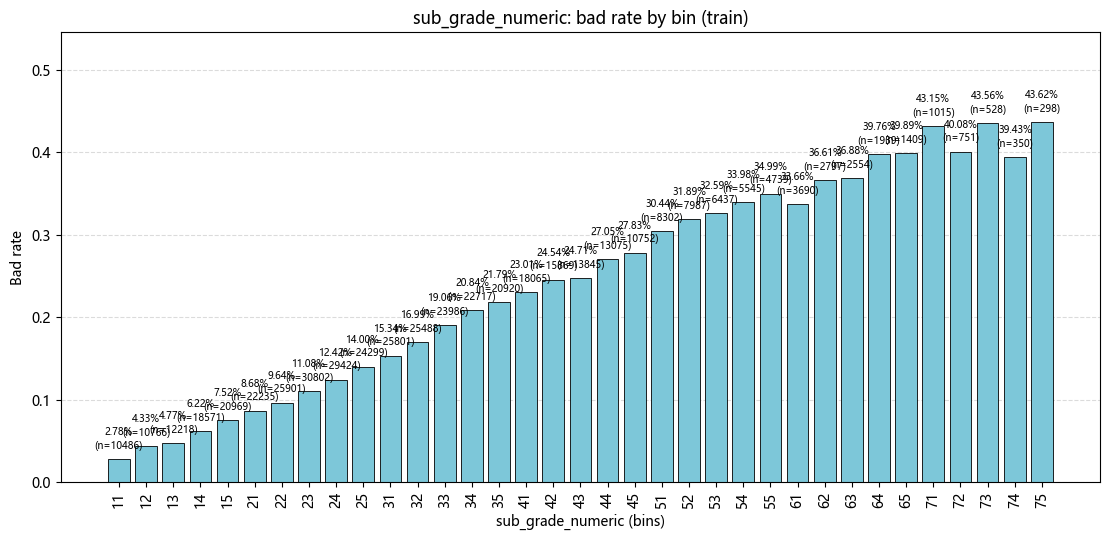

{'col': 'sub_grade_numeric',
 'target': 'target',
 'use_bins': False,
 'bin_edges': None,
 'woe_map': _bin
 11    1.967857
 12    1.510770
 13    1.408642
 14    1.128346
 15    0.925079
 21    0.768971
 22    0.652430
 23    0.497936
 24    0.368133
 25    0.230299
 31    0.122900
 32    0.001507
 33   -0.138629
 34   -0.250554
 35   -0.306866
 41   -0.376960
 42   -0.461559
 43   -0.470766
 44   -0.592939
 45   -0.631903
 51   -0.758438
 52   -0.826081
 53   -0.858284
 54   -0.920604
 55   -0.965301
 61   -0.906395
 62   -1.035987
 63   -1.047718
 64   -1.169584
 65   -1.174745
 71   -1.309320
 72   -1.182806
 73   -1.325929
 74   -1.155611
 75   -1.328514
 Name: woe, dtype: float64,
 'method': 'quantile',
 'bins': 35,
 'force_bins': False,
 'eps': 1e-06}

In [ ]:
plot_bad_rate_by_bin(df_train_3, 'sub_grade_numeric', target='target', bins=35, method='quantile')

In [ ]:
sub_grade_numeric = df_train_3['sub_grade_numeric'].dropna().unique()
print(f"📌 sub_grade_numeric unqiue values：{len(sub_grade_numeric)}")
print(sub_grade_numeric[:10])


📌 sub_grade_numeric unqiue values：35
[13 31 33 41 34 25 45 24 42 23]


# We analyzed these variables
# We can find the pattern between bad rate and these variables
## Current Feature Processing

### Ordinal / Numeric Encoding
- `sub_grade_numeric`: divide by `100`
- `verification_status`: encode as `0 / 1 / 2`
- `initial_list_status`: encode as `0 / 1`
- `term`: encode as `36 / 60`

### One-Hot Encoding
- `is_small_business`: create based on `purpose`
- `homeownership`: apply one-hot encoding

### Keep Existing WOE Encoding
- `addr_modified`: keep WOE encoding

### Variables for WOE-Based Binning Review
- `credit_history_length_days`: `plot_woe_by_bin`
- `installment`: `plot_woe_by_bin`

### Variables for Decision-Tree Binning Review
- `delinq_2yrs`: `plot_decision_tree_bins`
- `inq_last_6mths`: `plot_decision_tree_bins`
- `fico_range_low`: `plot_decision_tree_bins`
- `annual_inc`: `plot_decision_tree_bins`
- `revol_util`: `plot_decision_tree_bins`
- `revol_bal`: `plot_decision_tree_bins`
- `open_acc`: `plot_decision_tree_bins`
- `pub_rec`: `plot_decision_tree_bins`
- `int_rate`: `plot_decision_tree_bins`
- `total_acc`: `plot_decision_tree_bins`

### Variables for Bad-Rate Binning Review
- `loan_amnt`: `plot_bad_rate_by_bin(10)`
- `total_rec_int`: `plot_bad_rate_by_bin`

---



### We skip other variables this time, but we will further explore them.

# after initial EAD and feature engineering, we can try to build a model

In [ ]:
df_train_4 = df_train_3.copy(deep=False)
df_test_4 = df_test_3.copy(deep=False)

In [ ]:
df_train_4.to_csv("df_train_4.csv", index=False)

In [ ]:
import pandas as pd


import numpy as np
import pandas as pd

def _to_float_series(x, index, fillna_woe=0.0):
    s = pd.Series(x, index=index, copy=False)
    s = s.astype("object")
    s = pd.to_numeric(s, errors="coerce")
    return s.fillna(fillna_woe)

import numpy as np
import pandas as pd

def col_to_woe(df, bundle, fillna_woe=0.0):
    if bundle is None:
        return pd.Series(fillna_woe, index=df.index, dtype="float64")

    binned = apply_woe_bins(df, bundle)

    if isinstance(binned, pd.Series):
        binned = binned.astype("object")
    else:
        binned = pd.Series(binned, index=df.index).astype("object")

    woe = map_to_train_woe(binned, bundle)
    woe = pd.Series(woe, index=df.index).astype("object")
    woe = pd.to_numeric(woe, errors="coerce")

    return woe.fillna(fillna_woe)

def col_to_tree_woe(df, bundle, fillna_woe=0.0):
    if bundle is None:
        return pd.Series(fillna_woe, index=df.index, dtype="float64")
    leaves = apply_decision_tree_bins(df, bundle)
    return map_leaf_to_train_woe(leaves, bundle, fillna_woe=fillna_woe)

def col_to_bad_rate_woe(df, bundle, fillna_woe=0.0):
    if bundle is None:
        return pd.Series(fillna_woe, index=df.index, dtype="float64")
    binned = apply_woe_bins(df, bundle)
    woe = map_to_train_woe(binned, bundle)
    return _to_float_series(woe, df.index, fillna_woe)

def col_to_tree_woe_safe(df, bundle, fillna_woe=0.0):
    return col_to_tree_woe(df, bundle, fillna_woe)

def col_to_bad_rate_woe_safe(df, bundle, fillna_woe=0.0):
    return col_to_bad_rate_woe(df, bundle, fillna_woe)


def add_credit_history_length(
    df,
    issue_col="issue_d",
    earliest_col="earliest_cr_line",
    out="credit_history_length_days",
):
    d = df.copy()
    a = pd.to_datetime(d[issue_col], errors="coerce")
    b = pd.to_datetime(d[earliest_col], errors="coerce")
    d[out] = (a - b).dt.days
    return d


def term_to_60_flag(s):
    x = pd.to_numeric(
        s.astype(str).str.replace(" months", "", regex=False),
        errors="coerce",
    )
    return (x == 60).astype(float)


def build_features(
    train,
    test,
    fillna_woe=0.0,
    credit_col="credit_history_length_days",
    woe_bins=10,
    woe_method="quantile",
    loan_bins=10,
):

    import numpy as np

    tr = train.copy()
    te = test.copy()

    if credit_col not in tr.columns and {"issue_d", "earliest_cr_line"}.issubset(
        tr.columns
    ):
        tr = add_credit_history_length(tr, out=credit_col)
    if credit_col not in te.columns and {"issue_d", "earliest_cr_line"}.issubset(
        te.columns
    ):
        te = add_credit_history_length(te, out=credit_col)

    need = [
        "target",
        "sub_grade_numeric",
        "purpose",
        credit_col,
        "addr_modified",
        "delinq_2yrs",
        "verification_status",
        "inq_last_6mths",
        "fico_range_low",
        "annual_inc",
        "revol_util",
        "revol_bal",
        "initial_list_status",
        "open_acc",
        "pub_rec",
        "loan_amnt",
        "term",
        "installment",
    ]

    tr = tr[[c for c in need if c in tr.columns]].copy()
    te = te[[c for c in need if c in te.columns]].copy()
    out_tr = pd.DataFrame(index=tr.index)
    out_te = pd.DataFrame(index=te.index)

    if "sub_grade_numeric" in tr.columns:
        out_tr["sub_grade_numeric"] = tr["sub_grade_numeric"] / 100.0
        out_te["sub_grade_numeric"] = te["sub_grade_numeric"] / 100.0

    if "purpose" in tr.columns:
        out_tr["is_small_business"] = (tr["purpose"] == "small_business").astype(int)
        out_te["is_small_business"] = (te["purpose"] == "small_business").astype(int)
    # verification_status:
    if "verification_status" in tr.columns:
        verif_map = {"Not Verified": 0, "Source Verified": 1, "Verified": 2}
        out_tr["verification_status"] = tr["verification_status"].map(verif_map)
        out_te["verification_status"] = te["verification_status"].map(verif_map)

    # initial_list_status:
    if "initial_list_status" in tr.columns:
        ils_map = {"w": 0, "f": 1}
        out_tr["initial_list_status"] = tr["initial_list_status"].map(ils_map)
        out_te["initial_list_status"] = te["initial_list_status"].map(ils_map)

    if "term" in tr.columns:
        out_tr["is_term_60"] = term_to_60_flag(tr["term"])
        out_te["is_term_60"] = term_to_60_flag(te["term"])

    # ---------- 2. helpers ----------
    def add_woe_feature(col, out_name=None):
        if col not in tr.columns:
            return
        out_name = out_name or f"{col}_woe"
        bundle = plot_woe_by_bin(
            tr,
            col,
            target="target",
            bins=woe_bins,
            method=woe_method,
            show=False,
        )
        out_tr[out_name] = col_to_woe(tr, bundle, fillna_woe=fillna_woe)
        out_te[out_name] = col_to_woe(te, bundle, fillna_woe=fillna_woe)

    def add_tree_woe_feature(col, out_name=None):
        if col not in tr.columns:
            return
        out_name = out_name or f"{col}_tree_woe"
        bundle = plot_decision_tree_bins(tr, col, target="target", show=False)
        out_tr[out_name] = col_to_tree_woe_safe(tr, bundle, fillna_woe=fillna_woe)
        out_te[out_name] = col_to_tree_woe_safe(te, bundle, fillna_woe=fillna_woe)

    def add_bad_rate_woe_feature(col, out_name=None, bins=10):
        if col not in tr.columns:
            return
        out_name = out_name or f"{col}_br_woe"
        bundle = plot_bad_rate_by_bin(
            tr, col, target="target", bins=bins, method="quantile", show=False
        )
        out_tr[out_name] = col_to_bad_rate_woe_safe(tr, bundle, fillna_woe=fillna_woe)
        out_te[out_name] = col_to_bad_rate_woe_safe(te, bundle, fillna_woe=fillna_woe)

    # ---------- 3. WOE ----------
    add_woe_feature(credit_col, f"{credit_col}_woe")
    add_woe_feature("addr_modified", "addr_modified_woe")
    add_woe_feature("installment", "installment_woe")

    tree_cols = [
        "delinq_2yrs",
        "inq_last_6mths",
        "fico_range_low",
        "annual_inc",
        "revol_util",
        "revol_bal",
        "open_acc",
        "pub_rec",
    ]
    for c in tree_cols:
        add_tree_woe_feature(c, f"{c}_tree_woe")

    add_bad_rate_woe_feature("loan_amnt", "loan_amnt_br_woe", bins=loan_bins)

    if "target" in tr.columns:
        out_tr["target"] = tr["target"]
    if "target" in te.columns:
        out_te["target"] = te["target"]
    return out_tr, out_te



In [ ]:
# df_train_4

In [ ]:
# df_test_4["target"]

In [ ]:
train, test = build_features(df_train_4, df_test_4)

In [ ]:
# test["target"]

0         0
1         0
2         0
3         0
4         0
         ..
375540    0
375541    0
375542    1
375543    1
375544    0
Name: target, Length: 375545, dtype: int64

In [ ]:
target_col = "target"

X_train = train.drop(columns=[target_col])
y_train = train[target_col]

X_test = test.drop(columns=[target_col])
y_test = test[target_col]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_train = train["target"]
y_test  = test["target"]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=500,
        penalty='l2',
        random_state=42,
        solver='liblinear'
    )),
])

model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
pred_test = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("Accuracy:", accuracy_score(y_test, pred_test))
print("Precision:", precision_score(y_test, pred_test, zero_division=0))
print("Recall:", recall_score(y_test, pred_test, zero_division=0))
print("F1:", f1_score(y_test, pred_test, zero_division=0))
print("\nClassification Report:")
print(classification_report(y_test, pred_test, zero_division=0))

ROC-AUC: 0.7237937227099696
Accuracy: 0.6839233647099549
Precision: 0.34442590846449556
Recall: 0.6264395868237405
F1: 0.44447356474613076

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78    299742
           1       0.34      0.63      0.44     75803

    accuracy                           0.68    375545
   macro avg       0.61      0.66      0.61    375545
weighted avg       0.77      0.68      0.71    375545



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    pred_t = (proba_test >= t).astype(int)
    print(f"Threshold = {t:.1f}")
    print("ROC-AUC:", roc_auc_score(y_test, proba_test))
    print("Accuracy :", accuracy_score(y_test, pred_t))
    print("Precision:", precision_score(y_test, pred_t, zero_division=0))
    print("Recall   :", recall_score(y_test, pred_t, zero_division=0))
    print("F1       :", f1_score(y_test, pred_t, zero_division=0))
    print("-" * 40)

Threshold = 0.1
ROC-AUC: 0.7237937227099696
Accuracy : 0.2020476906895312
Precision: 0.20188829999733668
Recall   : 1.0
F1       : 0.3359518517615723
----------------------------------------
Threshold = 0.2
ROC-AUC: 0.7237937227099696
Accuracy : 0.24655900091866487
Precision: 0.21043964953284092
Recall   : 0.9930081922879042
F1       : 0.3472826801569561
----------------------------------------
Threshold = 0.3
ROC-AUC: 0.7237937227099696
Accuracy : 0.37889733587186625
Precision: 0.23778865081453404
Recall   : 0.9418096909093308
F1       : 0.37970832579859376
----------------------------------------
Threshold = 0.4
ROC-AUC: 0.7237937227099696
Accuracy : 0.5414131462274827
Precision: 0.2814515946233878
Recall   : 0.8190177169769006
F1       : 0.41893733889361245
----------------------------------------
Threshold = 0.5
ROC-AUC: 0.7237937227099696
Accuracy : 0.6839233647099549
Precision: 0.34442590846449556
Recall   : 0.6264395868237405
F1       : 0.44447356474613076
----------------------

In [ ]:
train, test = df_train_4.copy(), df_test_4.copy()

In [ ]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)
y_train = train["target"]
y_test = test["target"]

model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
pred_test = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("Accuracy:", accuracy_score(y_test, pred_test))
print(
    "Precision:", precision_score(y_test, pred_test, zero_division=0),
    "Recall:", recall_score(y_test, pred_test, zero_division=0),
    "F1:", f1_score(y_test, pred_test, zero_division=0),
)

[LightGBM] [Info] Number of positive: 75613, number of negative: 368917
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 173
[LightGBM] [Info] Number of data points in the train set: 444530, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
ROC-AUC: 0.7279059998194494
Accuracy: 0.6694350876725825
Precision: 0.33718650849786796 Recall: 0.660330066092371 F1: 0.4464174232559799


In [ ]:
# Final Result:
# Threshold = 0.5
# ROC-AUC: 0.7237937227099696
# Accuracy : 0.6839233647099549
# Precision: 0.34442590846449556
# Recall   : 0.6264395868237405
# F1       : 0.44447356474613076


# Final Result

## Logistic Regression Final Performance

Using **Logistic Regression** with `class_weight='balanced'` and a classification **threshold = 0.5`, the final test-set performance is:

- **ROC-AUC:** 0.7238
- **Accuracy:** 0.6839
- **Precision:** 0.3444
- **Recall:** 0.6264
- **F1 Score:** 0.4445

---

## Interpretation

- The model achieves a **ROC-AUC of 0.7238**, indicating a moderate ability to distinguish between good and bad borrowers.
- Compared with the unweighted logistic regression model, the balanced version significantly improves **recall**, meaning it is much better at identifying bad borrowers.
- The trade-off is a lower **precision** and **accuracy**, which suggests that the model captures more bad borrowers at the cost of introducing more false positives.
- Overall, this version is more suitable as a **risk-screening baseline model**, especially in a credit risk setting where capturing bad borrowers is more important than maximizing overall accuracy.

---

## Conclusion

This balanced logistic regression model provides a more practical baseline for the LendingClub default prediction task:

- It maintains similar ranking ability (**AUC remains stable**),
- while substantially improving bad-borrower detection (**Recall = 0.6264**).

Therefore, this model can serve as the current baseline for further improvement through:

1. deeper feature engineering,
2. threshold tuning,
3. logistic regression hyperparameter tuning,
4. and comparison with tree-based models such as **XGBoost** and **LightGBM**.

# Next Steps(Maybe)

## 1. Feature Engineering

### 1.1 Revisit previously dropped variables
- Review the variables that were removed earlier.
- Focus especially on the variables with only moderate missingness rather than extremely high missingness.
- Re-evaluate whether some of these variables still contain useful predictive information.

### 1.2 Continue exploring the remaining variables
- Inspect the distributions, bad rate trends, and missing patterns of the remaining variables.
- Check whether additional binning, WOE encoding, or transformation is needed.
- Identify fields with potential business meaning that have not yet been fully utilized.

### 1.3 Build stronger derived features
- Create ratio-based features, such as:
  - `loan_amnt / annual_inc`
  - `installment / annual_inc`
  - `revol_bal / annual_inc`
- Create time-based and intensity-based features where applicable.
- Add transformed variables such as log-transformed income or revolving balance if the original distributions are highly skewed.

### 1.4 Try feature interactions
- Test combinations of key fields, especially:
  - credit quality × repayment burden
  - grade/sub-grade × FICO
  - loan amount × income
  - inquiries/delinquencies × open accounts
- Compare whether these interaction features improve model performance.

---

## 2. Modeling Preparation

### 2.1 Check correlation before modeling
- Compute the correlation matrix for numerical variables.
- Identify highly correlated variables.
- For highly correlated variables, consider:
  - dropping redundant variables
  - keeping only the more interpretable variable
  - dimensionality reduction if necessary

### 2.2 Perform feature selection if needed
- Use correlation analysis, IV, model coefficients, or importance scores to reduce redundancy.
- Keep the final feature set stable and interpretable.

---

## 3. Modeling Experiments

### 3.1 Improve Logistic Regression
- Tune logistic regression hyperparameters, especially:
  - `C`
  - `class_weight`
  - `penalty`
- Compare different thresholds instead of relying only on the default 0.5 cutoff.
- Evaluate performance using:
  - ROC-AUC
  - Precision
  - Recall
  - F1
  - business-oriented bad capture rate

### 3.2 Try SMOTE
- Test whether SMOTE improves minority-class detection on the training data.
- Compare SMOTE with:
  - no resampling
  - class_weight balancing
- Carefully monitor whether recall improvement comes at the cost of too many false positives.

### 3.3 Try tree-based boosting models
- Train and tune:
  - XGBoost
  - LightGBM
- Compare their performance against logistic regression.
- Focus on:
  - ROC-AUC
  - recall/precision tradeoff
  - feature importance
  - model stability

---

## 4. Evaluation and Comparison

### 4.1 Build a model comparison table
- Compare:
  - Logistic Regression baseline
  - Logistic Regression + tuning
  - Logistic Regression + SMOTE
  - XGBoost
  - LightGBM

### 4.2 Select the next benchmark model
- Choose the model with the best balance between:
  - predictive power
  - interpretability
  - stability
  - business usability

---



In [ ]:
# Final Result:
# Threshold = 0.5
# ROC-AUC: 0.7237937227099696
# Accuracy : 0.6839233647099549
# Precision: 0.34442590846449556
# Recall   : 0.6264395868237405
# F1       : 0.44447356474613076

#What we can talk about during the meeting

# LendingClub Default Prediction Project

## What We Have Done So Far

### 1. Data Wrangling and Data Cleaning

We completed the initial data preprocessing and cleaning with the following steps:

- Dropped columns with a **high missing rate** (greater than 50%)
- Removed **zero-variance columns** and **constant columns** (columns with only one unique value)
- Filtered variables based on **Information Value (IV)**:
  - Dropped variables with **IV that was too high**, as they were suspected to contain leakage
  - Dropped variables with **IV that was too low**, as they were considered uninformative

#### Information Value (IV)
Information Value (IV) measures the predictive power of an independent variable for a binary target variable, such as **default vs. non-default**. It is widely used in **credit scoring** and **logistic regression modeling**.

#### Population Stability Index (PSI)
Population Stability Index (PSI) is an important metric in credit scoring that measures how much the distribution of borrower data or risk scores changes between a **baseline period** (for example, the model development period) and a **current period**. It is commonly used to detect **data drift** or **model drift**.

---

### 2. Exploratory Data Analysis (EDA) and Feature Engineering

We then conducted further EDA and feature engineering. The variables we focused on include:

- **earliest_cr_line**  
  The month when the borrower's earliest reported credit line was opened

- **dti**  
  A ratio calculated as the borrower's total monthly debt payments on total debt obligations, excluding mortgage and the requested LendingClub loan, divided by the borrower's self-reported monthly income

- **issue_d**  
  We examined the relationship between the loan issue time and the default rate

- **loan_amnt**  
  The listed amount of the loan applied for by the borrower

- **int_rate**  
  The interest rate on the loan

- **grade** and **sub_grade**  
  LendingClub’s assigned loan grade and sub-grade

- **term**  
  The number of payments on the loan, typically **36 months** or **60 months**

- **installment**  
  The monthly payment owed by the borrower if the loan is originated

- **annual_inc**  
  The self-reported annual income provided by the borrower during registration

- **open_acc**  
  The number of open credit lines in the borrower’s credit file

- **revol_util**  
  The amount of revolving credit the borrower is using relative to total available revolving credit

- **purpose**  
  The stated purpose of the loan

- **addr_state**  
  The state provided by the borrower in the loan application

- **fico_range_high**  
  The upper bound of the borrower’s FICO score range at loan origination

---

### 3. Variable Binning

We applied **binning** to the variables selected for modeling.

In risk control and credit scoring scenarios, binning is especially useful because it helps:

- **smooth noisy data**
- **reduce the impact of outliers**
- **capture non-linear relationships**
- **enhance interpretability**
- improve the effectiveness of **logistic regression**
- support later **WOE encoding** and **scorecard development**

---

### 4. Modeling

We built a **Logistic Regression** model and obtained the following results:

```python
# Final Result:
# Threshold = 0.5
# ROC-AUC: 0.7237937227099696
# Accuracy : 0.6839233647099549
# Precision: 0.34442590846449556
# Recall   : 0.6264395868237405
# F1       : 0.44447356474613076

## Questions for Further Discussion

### 1. What is the best workflow?
Should we first build a baseline model and run the full process quickly, then improve it step by step, or should we spend more time on thorough EDA before building the first model?

### 2. How do distribution and correlation analysis help modeling?
We often examine variable distributions, time trends, and correlations in case studies. But how do these analyses actually help the model?

For example:
- How does checking the distribution of `int_rate` help with model building?
- Why does the relationship between a variable and time matter?
- How can these findings improve feature selection, binning, and model stability?

### 3. What should we do next to improve the model?
If we want to improve model performance, what should our next steps be?

For example, should we focus more on:
- feature engineering
- interaction features
- time-related features
- better binning strategies
- WOE transformation
- class imbalance handling
- model tuning
- more advanced models such as tree-based methods

We also want to know which variables are usually most important in a LendingClub default prediction task, and which types of new features are most likely to improve performance.